# BC-CIRL Setpoint Policy Evaluation — **Anti-Windup**
Rolls out `cql_cirl_setpoint_anti_windup_*.pt` policies in closed loop.

Matches `BC_CIRL_Setpoint_Anti_Windup.py`:
* **Bumpless start** — integral pre-loaded so the first control increment is 0 (`int_e = -Kp*e0/Ki`).
* **Back-calculation anti-windup** — `int_e += (e + Kw*(q_sat - q_raw))*Ts`, `Kw = Ki/Kp`.
* Flow limits **0-40 L/min**, `Kw` pinned to the expert constant `Ki/Kp`.

T_ref auto-selected: cloudy 65°C, sunny 80°C. Reference is constant (no ramp).

In [1]:
# ── Setup: shared library (../../main_script) + this folder's config ─────────
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
_here = os.getcwd()
PKG = os.path.dirname(_here) if os.path.basename(_here).lower() == "evaluate" else _here
sys.path.insert(0, PKG)                       # for config
sys.path.insert(0, os.path.dirname(PKG))      # For GitHub -> main_script
from main_script import *
import config_cirl as cfg
from config_cirl import *
configure(cfg)
BASE_DIR = PKG
SAVE_DIR  = cfg.SAVE_DIR
CHART_DIR = cfg.CHART_DIR; os.makedirs(CHART_DIR, exist_ok=True)

EVAL_DATASET = "20_10_2025__Cloudy_Closed_Loop.xlsx"
EVAL_LABEL   = "_".join(EVAL_DATASET.split("_")[:3])
TREF   = dataset_tref(EVAL_DATASET)
DQ_MAX = 10.0
GROUP_COLORS = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c", 4: "#9467bd"}
OBS_LOW_9D = OBS_LOW; OBS_HIGH_9D = OBS_HIGH
def normalize_obs_9d(state): return normalize_obs(state)
def CIRLBCNet(in_dim=9): return GainActor(in_dim=in_dim, out_dim=3)
PREFIX = "cql_cirl_setpoint_anti_windup_"

print("Setup via main_script | EVAL_DATASET:", EVAL_DATASET, "| TREF:", TREF)


Setup via main_script | EVAL_DATASET: 20_10_2025__Cloudy_Closed_Loop.xlsx | TREF: 65.0


In [2]:
# ── Load dataset from Excel ────────────────────────────────────────────────────
def load_dataset(filename):
    path = os.path.join(BASE_DIR, 'data', filename)
    df   = pd.read_excel(path)
    return dict(
        T_sc   = df['T_sc'].to_numpy(dtype=np.float64),
        Tin    = df['Tin'].to_numpy(dtype=np.float64),
        Ta     = df['Ta'].to_numpy(dtype=np.float64),
        I_sol  = df['I'].to_numpy(dtype=np.float64),
        theta  = df['theta'].to_numpy(dtype=np.float64),
        q      = df['q'].to_numpy(dtype=np.float64),
        time_ax= np.arange(len(df), dtype=np.float64) * TS,
        N      = len(df),
        name   = filename,
    )

data      = load_dataset(EVAL_DATASET)
T_sc_meas = data['T_sc']
time_ax   = data['time_ax']

print(f"Dataset  = {data['N']} steps  ({EVAL_DATASET})")
print(f"T_sc : mean={T_sc_meas.mean():.2f}°C  "
      f"min={T_sc_meas.min():.2f}°C  max={T_sc_meas.max():.2f}°C")
print(f"T_ref = {TREF}°C  (constant — {'cloudy' if TREF == TREF_CLOUDY else 'sunny'} dataset)")

Dataset  = 19801 steps  (20_10_2025__Cloudy_Closed_Loop.xlsx)
T_sc : mean=58.58°C  min=45.10°C  max=69.60°C
T_ref = 65.0°C  (constant — cloudy dataset)


In [3]:
# ── Discover all 'with_Kw' policies ─────────────────────────────────────────
bc_files = sorted([
    f for f in os.listdir(SAVE_DIR)
    if f.startswith(PREFIX) and f.endswith('.pt')
    and not f.endswith('_best.pt')
])

policies = []
for fname in bc_files:
    combo_name = fname[len(PREFIX):].replace('.pt', '')   # strip full prefix
    days = [d for d in combo_name.split('_') if d.startswith('s')]
    policies.append({
        'fname':      fname,
        'path':       os.path.join(SAVE_DIR, fname),
        'combo_name': combo_name,
        'days':       days,
        'n_files':    len(days),
    })

print(f"Found {len(policies)} 'with_Kw' policies:")
for p in policies:
    print(f"  [{p['n_files']}d]  {p['fname']}")

Found 15 'with_Kw' policies:
  [1d]  cql_cirl_setpoint_anti_windup_s21.pt
  [2d]  cql_cirl_setpoint_anti_windup_s21_s22.pt
  [3d]  cql_cirl_setpoint_anti_windup_s21_s22_s23.pt
  [4d]  cql_cirl_setpoint_anti_windup_s21_s22_s23_s24.pt
  [3d]  cql_cirl_setpoint_anti_windup_s21_s22_s24.pt
  [2d]  cql_cirl_setpoint_anti_windup_s21_s23.pt
  [3d]  cql_cirl_setpoint_anti_windup_s21_s23_s24.pt
  [2d]  cql_cirl_setpoint_anti_windup_s21_s24.pt
  [1d]  cql_cirl_setpoint_anti_windup_s22.pt
  [2d]  cql_cirl_setpoint_anti_windup_s22_s23.pt
  [3d]  cql_cirl_setpoint_anti_windup_s22_s23_s24.pt
  [2d]  cql_cirl_setpoint_anti_windup_s22_s24.pt
  [1d]  cql_cirl_setpoint_anti_windup_s23.pt
  [2d]  cql_cirl_setpoint_anti_windup_s23_s24.pt
  [1d]  cql_cirl_setpoint_anti_windup_s24.pt


In [4]:
# ── Rollout helpers — positional PI, bumpless start, back-calculation anti-windup
#    (matches Main_aggresive.m / BC_CIRL_Setpoint_Anti_Windup.py)
def rollout_expert(data, tref=None):
    if tref is None:
        tref = dataset_tref(data['name'])
    Tin=data['Tin']; I=data['I_sol']; Ta=data['Ta']
    th=data['theta']; T_sc=data['T_sc']; qm=data['q']; N=data['N']
    tout=float(T_sc[0]); tout_prev=tout
    e0 = tref - tout
    int_e = (float(qm[0]) - KP_EXPERT * e0) / KI_EXPERT   # bumpless: q_raw(0)=q[0]
    Kw = KI_EXPERT / KP_EXPERT
    Tout_list=[]; q_list=[]
    for t in range(N - 1):
        e  = tref - tout
        de = -(tout - tout_prev) / TS
        u  = KP_EXPERT * e + KI_EXPERT * int_e
        q_raw = u                                   # positional control output
        q  = float(np.clip(q_raw, Q_MIN, Q_MAX))
        int_e = float(np.clip(int_e + (e + Kw * (q - q_raw)) * TS, -INT_E_CLIP, INT_E_CLIP))
        tout_next = solar_model(q, Tin[t], I[t], Ta[t], th[t], tout)
        Tout_list.append(tout_next); q_list.append(q)
        tout_prev = tout; tout = tout_next
    return np.array(Tout_list), np.array(q_list)


def rollout_bc_cirl_setpoint_update(weights_path, data, tref=None):
    if tref is None:
        tref = dataset_tref(data['name'])
    model = CIRLBCNet(in_dim=9)
    model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
    model.eval()

    Tin=data['Tin']; I=data['I_sol']; Ta=data['Ta']
    th=data['theta']; T_sc=data['T_sc']; qm=data['q']; N=data['N']
    tout=float(T_sc[0]); tout_prev=tout
    e0 = tref - tout
    int_e = (float(qm[0]) - KP_EXPERT * e0) / KI_EXPERT   # bumpless (nominal expert gains)
    Tout_list=[]; q_list=[]; Kp_list=[]; Ki_list=[]; Kw_list=[]

    with torch.no_grad():
        for t in range(N - 1):
            e  = tref - tout
            de = -(tout - tout_prev) / TS
            state  = np.array([tout, e, int_e, de, I[t], Ta[t], Tin[t], th[t], tref],
                               dtype=np.float32)
            s_norm = torch.from_numpy(normalize_obs_9d(state).reshape(1, -1))
            gains_norm = np.clip(model(s_norm).numpy()[0], 0.0, 1.0)
            Kp, Ki, Kw = denormalize_gains(gains_norm)   # Kw pinned to expert Ki/Kp
            u  = Kp * e + Ki * int_e
            q_raw = u                                   # positional control output
            q  = float(np.clip(q_raw, Q_MIN, Q_MAX))
            int_e = float(np.clip(int_e + (e + Kw * (q - q_raw)) * TS, -INT_E_CLIP, INT_E_CLIP))
            tout_next = solar_model(q, Tin[t], I[t], Ta[t], th[t], tout)
            Tout_list.append(tout_next); q_list.append(q)
            Kp_list.append(Kp); Ki_list.append(Ki); Kw_list.append(Kw)
            tout_prev = tout; tout = tout_next

    return (np.array(Tout_list), np.array(q_list),
            np.array(Kp_list), np.array(Ki_list), np.array(Kw_list))


# ── Run Expert PI (reference) ────────────────────────────────
Tout_exp, q_exp = rollout_expert(data)
err_exp = Tout_exp - TREF
print(f"Expert PI   MAE={np.mean(np.abs(err_exp)):.4f}°C  "
      f"RMSE={np.sqrt(np.mean(err_exp**2)):.4f}°C  (vs T_ref={TREF}°C)")

# ── Run all anti-windup policies ──────────────────────────
results = {}
for p in policies:
    combo = p['combo_name']
    print(f"  Rolling out {combo} ...", end='  ', flush=True)
    Tout, q, Kp_arr, Ki_arr, Kw_arr = rollout_bc_cirl_setpoint_update(p['path'], data)
    err   = Tout - TREF
    mae   = float(np.mean(np.abs(err)))
    rmse  = float(np.sqrt(np.mean(err ** 2)))
    max_e = float(np.max(np.abs(err)))
    results[combo] = {
        'Tout': Tout, 'q': q, 'error': err,
        'Kp': Kp_arr, 'Ki': Ki_arr, 'Kw': Kw_arr,
        'mae': mae, 'rmse': rmse, 'max_e': max_e,
        'Kp_mean': float(np.mean(Kp_arr)),
        'Ki_mean': float(np.mean(Ki_arr)),
        'Kw_mean': float(np.mean(Kw_arr)),
        'n_files': p['n_files'],
    }
    print(f"MAE={mae:.3f}°C  RMSE={rmse:.3f}°C  "
          f"Kp={results[combo]['Kp_mean']:.4f}  "
          f"Ki={results[combo]['Ki_mean']:.5f}  "
          f"Kw={results[combo]['Kw_mean']:.4f}")

print("\nAll rollouts complete.")

Expert PI   MAE=2.1095°C  RMSE=2.9148°C  (vs T_ref=65.0°C)
  Rolling out s21 ...  

MAE=0.744°C  RMSE=2.430°C  Kp=-1.8155  Ki=-0.02896  Kw=-0.1554
  Rolling out s21_s22 ...  

MAE=0.596°C  RMSE=2.063°C  Kp=-1.8951  Ki=-0.03778  Kw=-0.2313
  Rolling out s21_s22_s23 ...  

MAE=0.512°C  RMSE=1.781°C  Kp=-1.8153  Ki=-0.04464  Kw=-0.3413
  Rolling out s21_s22_s23_s24 ...  

MAE=0.502°C  RMSE=1.766°C  Kp=-1.8918  Ki=-0.04511  Kw=-0.3424
  Rolling out s21_s22_s24 ...  

...

MAE=0.511°C  RMSE=1.778°C  Kp=-1.7713  Ki=-0.04489  Kw=-0.3417
  Rolling out s22_s24 ...  

MAE=0.494°C  RMSE=1.754°C  Kp=-1.8951  Ki=-0.04634  Kw=-0.3426
  Rolling out s23 ...  

MAE=0.510°C  RMSE=1.789°C  Kp=-1.8748  Ki=-0.04381  Kw=-0.3410
  Rolling out s23_s24 ...  

MAE=0.501°C  RMSE=1.758°C  Kp=-1.7999  Ki=-0.04620  Kw=-0.3426
  Rolling out s24 ...  

MAE=0.590°C  RMSE=2.057°C  Kp=-1.9609  Ki=-0.03767  Kw=-0.2343

All rollouts complete.


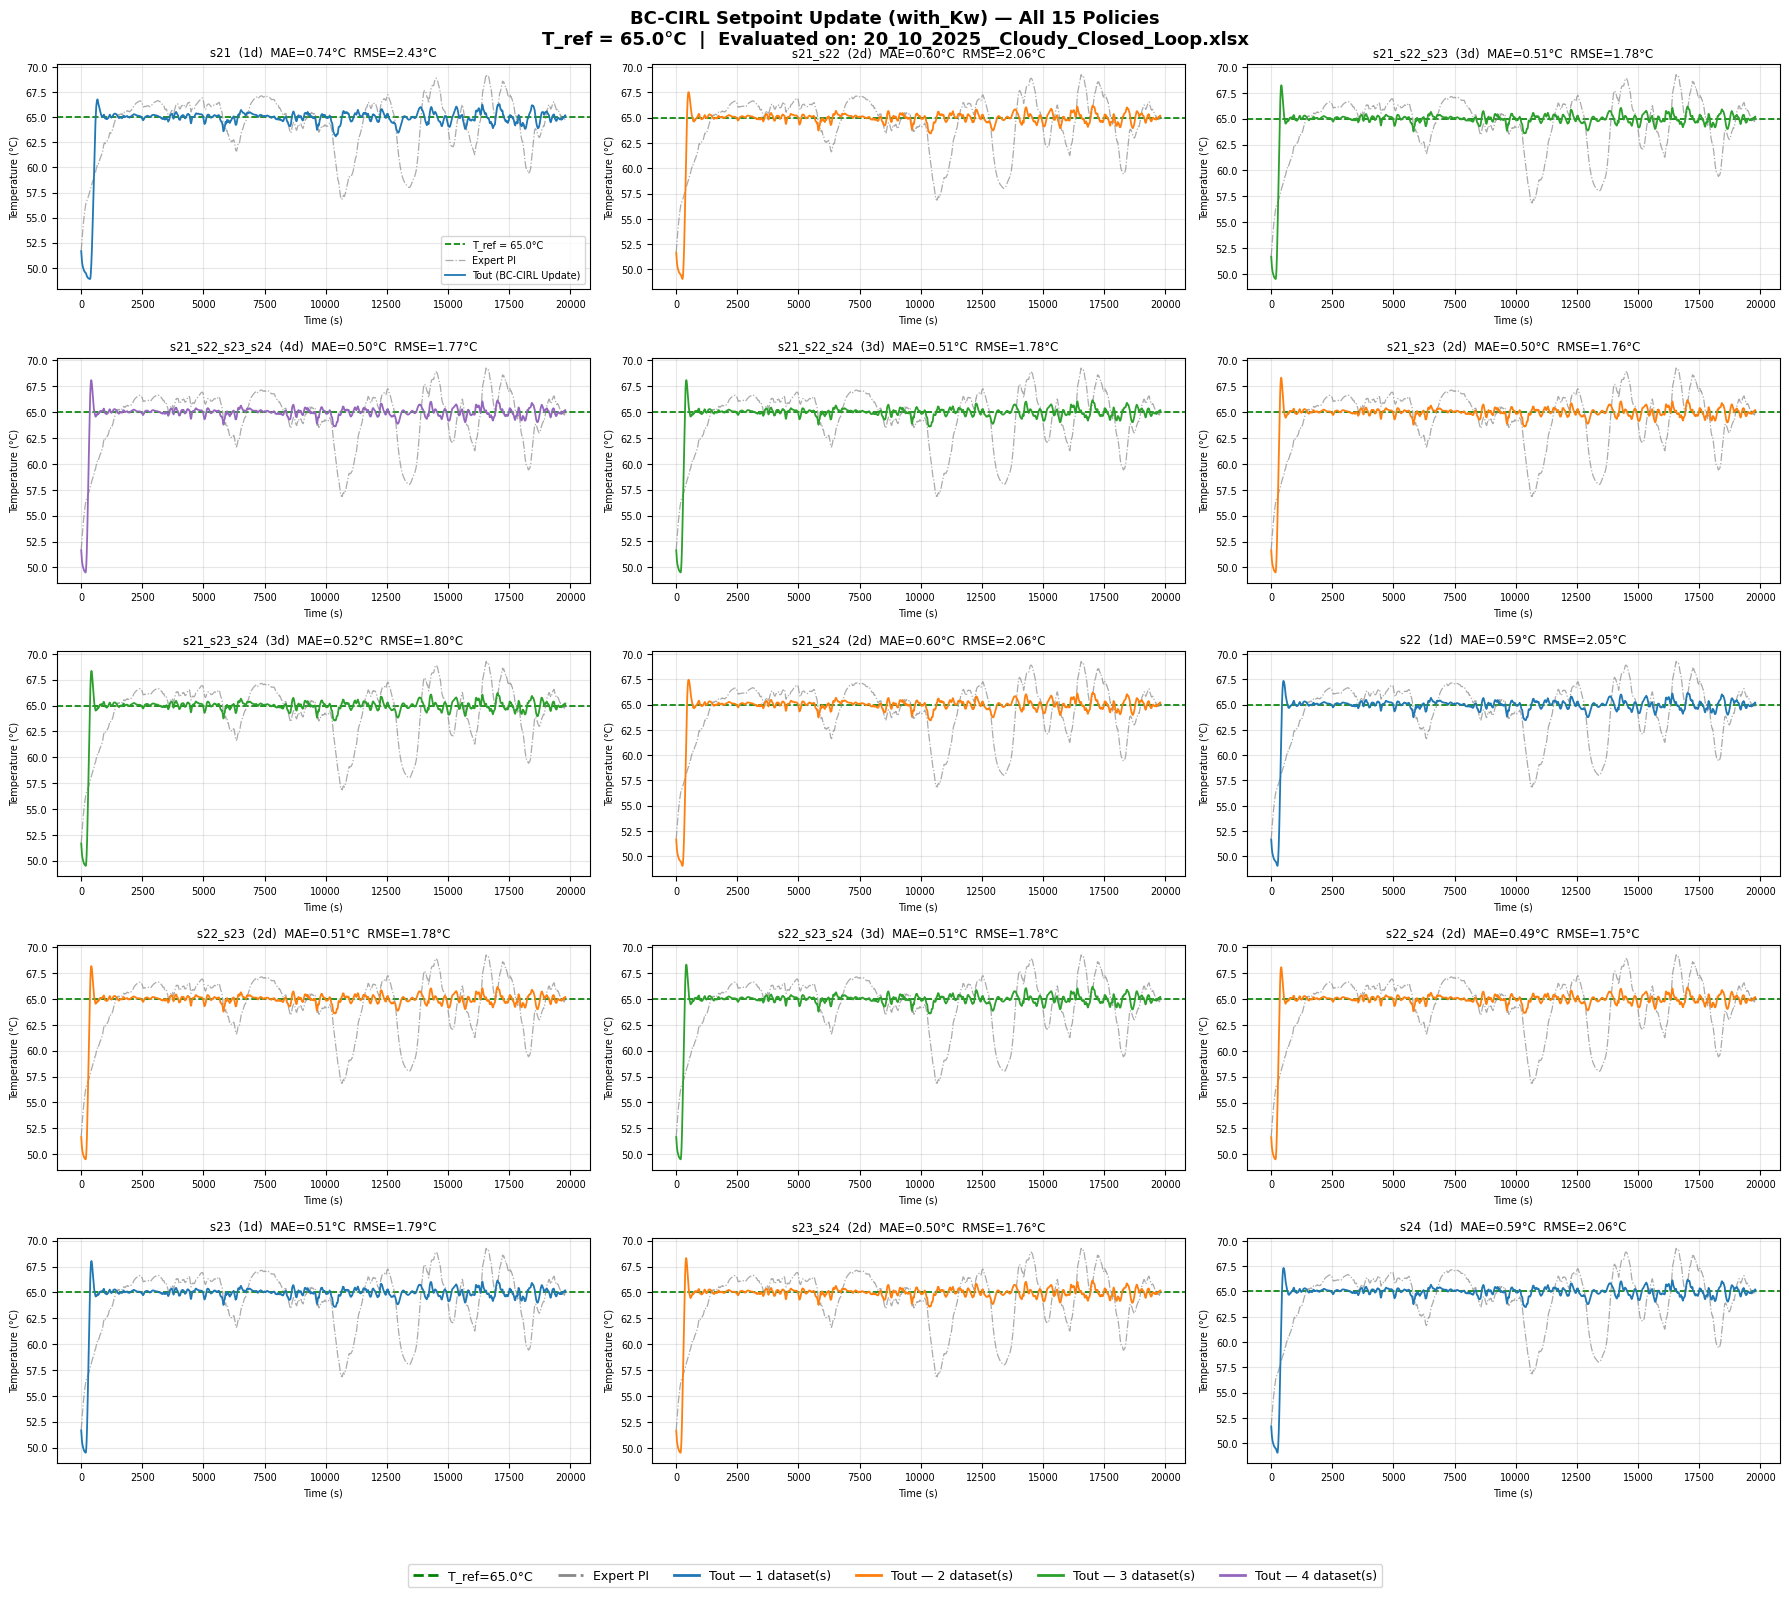

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\CQL Offline Actor\charts\cql_cirl_setpoint_anti_windup_grid_20_10_2025.png


In [5]:
# ── 5×3 grid: T_ref + Expert PI + Tout vs time ────────────────────────────────
n_cols = 3
n_rows = (len(policies) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2), sharex=False)
axes = axes.flatten()

for idx, p in enumerate(policies):
    combo = p['combo_name']
    ax    = axes[idx]

    if combo not in results:
        ax.set_title(f'{combo}  [no weights]', fontsize=9)
        ax.axis('off')
        continue

    r    = results[combo]
    Tout = r['Tout']
    t    = time_ax[1 : len(Tout) + 1]

    ax.axhline(TREF, color='green', linewidth=1.2, linestyle='--',
               label=f'T_ref = {TREF}°C')
    ax.plot(t, Tout_exp[:len(Tout)],
            color='#888888', linewidth=0.9, linestyle='-.', alpha=0.7, label='Expert PI')
    ax.plot(t, Tout,
            color=GROUP_COLORS.get(p['n_files'], '#333333'), linewidth=1.3,
            label='Tout (BC-CIRL Update)')

    ax.set_title(
        f"{combo}  ({p['n_files']}d)"
        f"  MAE={r['mae']:.2f}°C  RMSE={r['rmse']:.2f}°C",
        fontsize=8.5,
    )
    ax.set_ylabel('Temperature (°C)', fontsize=7)
    ax.set_xlabel('Time (s)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, loc='best')

for ax in axes[len(policies):]:
    ax.set_visible(False)

from matplotlib.lines import Line2D
color_handles = [
    Line2D([0],[0], color=GROUP_COLORS[n], linewidth=2, label=f'Tout — {n} dataset(s)')
    for n in sorted(GROUP_COLORS)
]
type_handles = [
    Line2D([0],[0], color='green',   linewidth=2, linestyle='--', label=f'T_ref={TREF}°C'),
    Line2D([0],[0], color='#888888', linewidth=2, linestyle='-.', label='Expert PI'),
]
fig.legend(handles=type_handles + color_handles,
           loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    f'BC-CIRL Setpoint Update (with_Kw) — All {len(policies)} Policies\n'
    f'T_ref = {TREF}°C  |  Evaluated on: {EVAL_DATASET}',
    fontsize=13, fontweight='bold',
)
fig.tight_layout(rect=[0, 0.04, 1, 1])

out = os.path.join(CHART_DIR, f'cql_cirl_setpoint_anti_windup_grid_{EVAL_LABEL}.png')
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")

Running rollouts for all policies on all 5 datasets...
  (T_ref auto-selected: cloudy→65°C, sunny→80°C)



  s21                     avg MAE=0.612°C


  s21_s22                 avg MAE=0.487°C


  s21_s22_s23             avg MAE=0.410°C


  s21_s22_s23_s24         avg MAE=0.403°C


...

  s22_s23_s24             avg MAE=0.410°C


  s22_s24                 avg MAE=0.397°C


  s23                     avg MAE=0.408°C


  s23_s24                 avg MAE=0.401°C


  s24                     avg MAE=0.483°C

Best-generalising policy (lowest avg MAE across all 5 datasets): s22_s24  (avg MAE=0.3973°C)

All rollouts done.


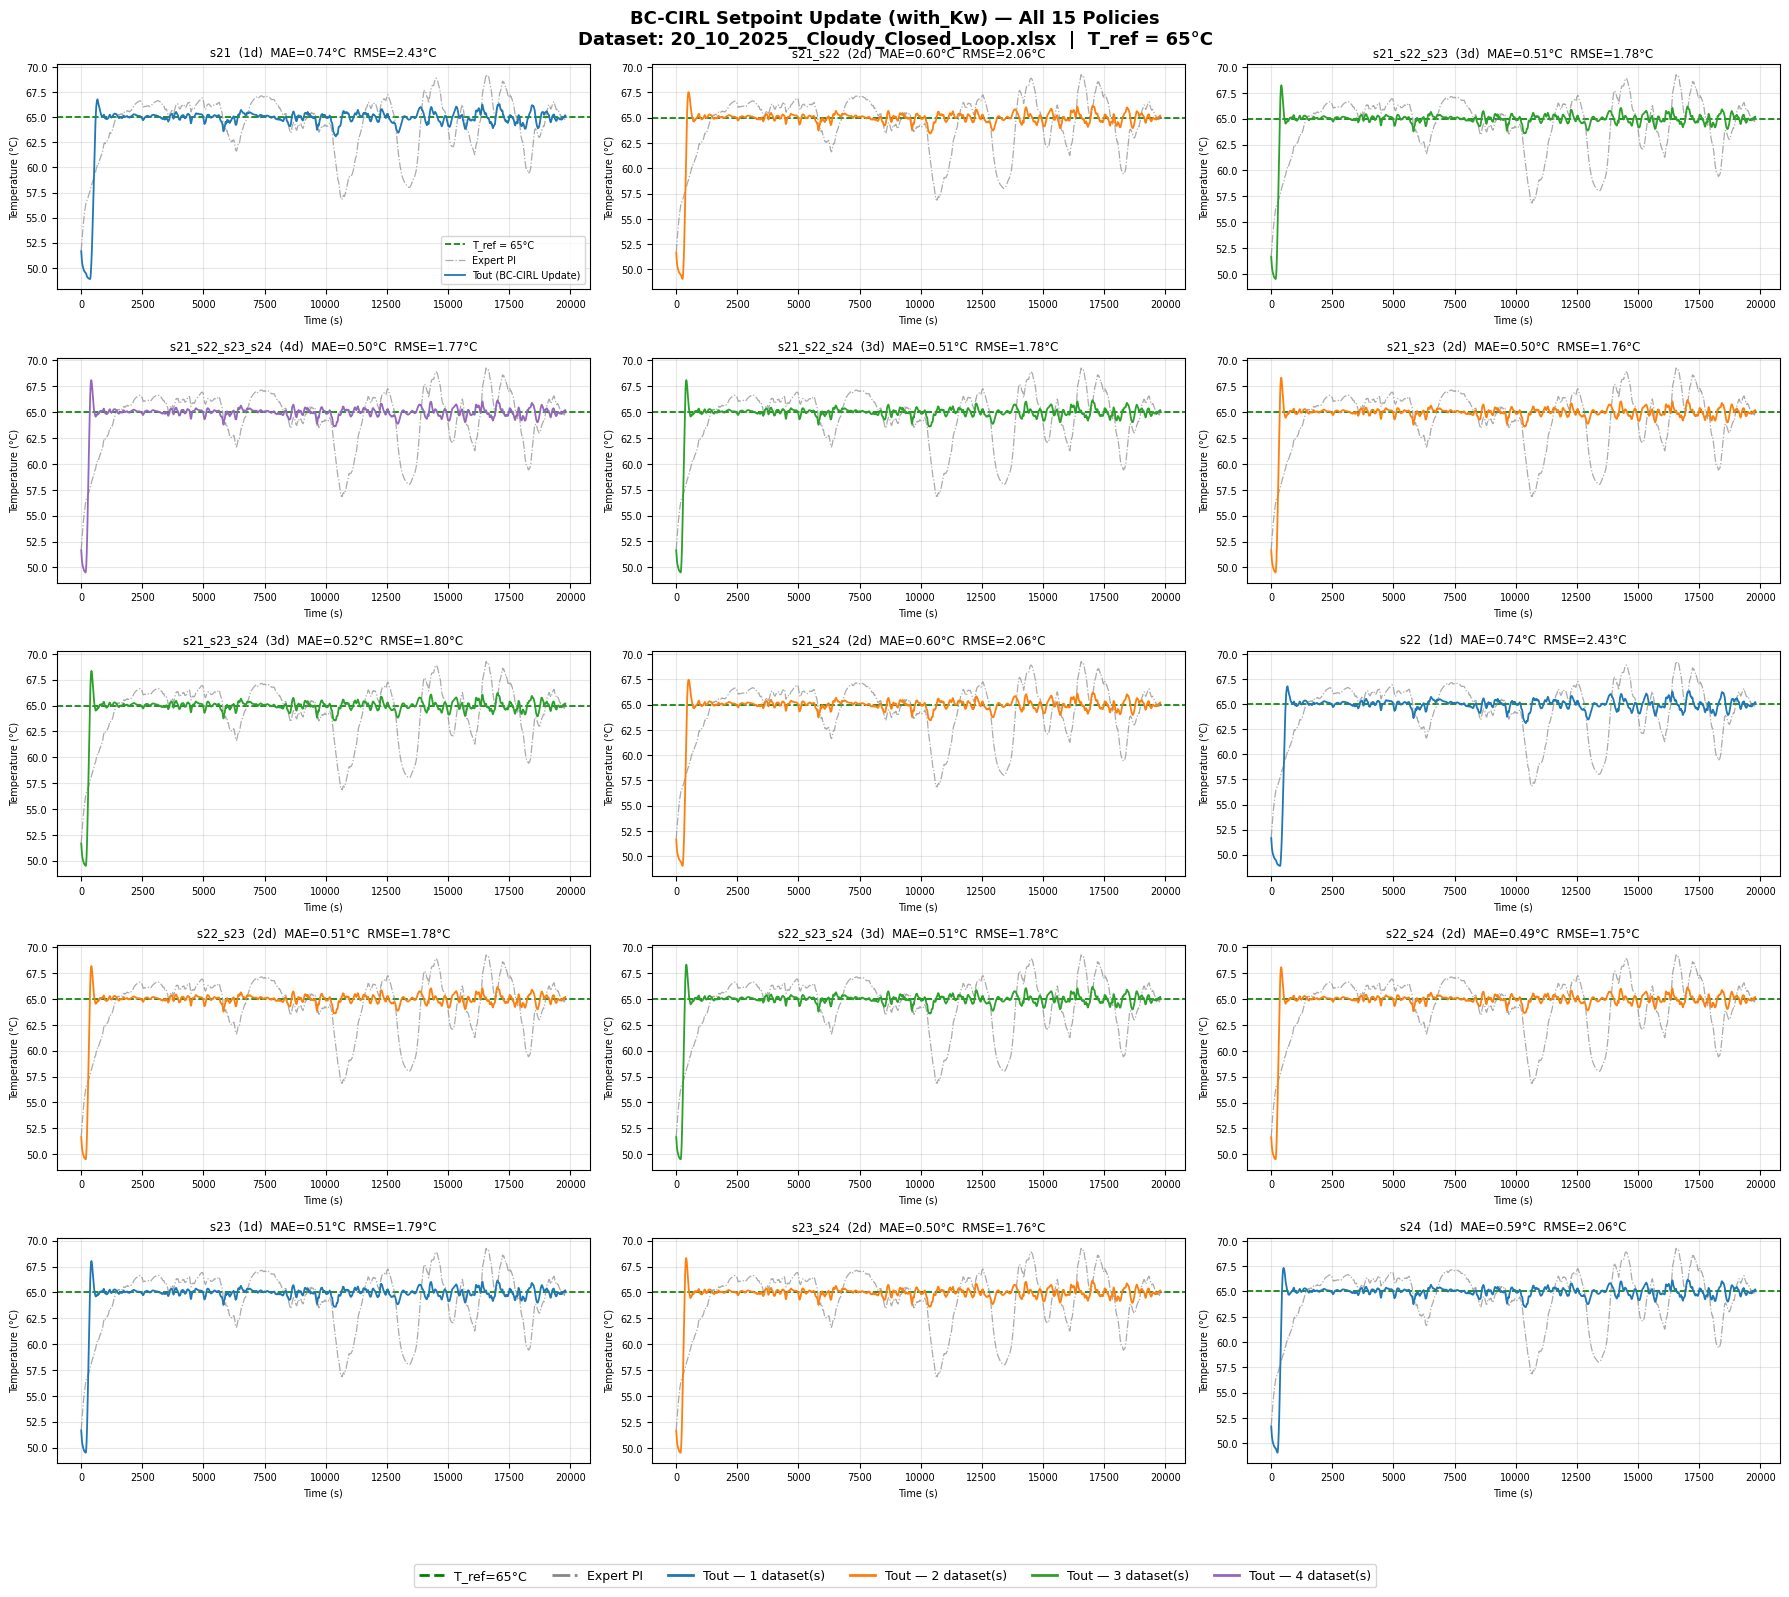

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\CQL Offline Actor\charts\cql_cirl_setpoint_anti_windup_grid_s20_65C.png


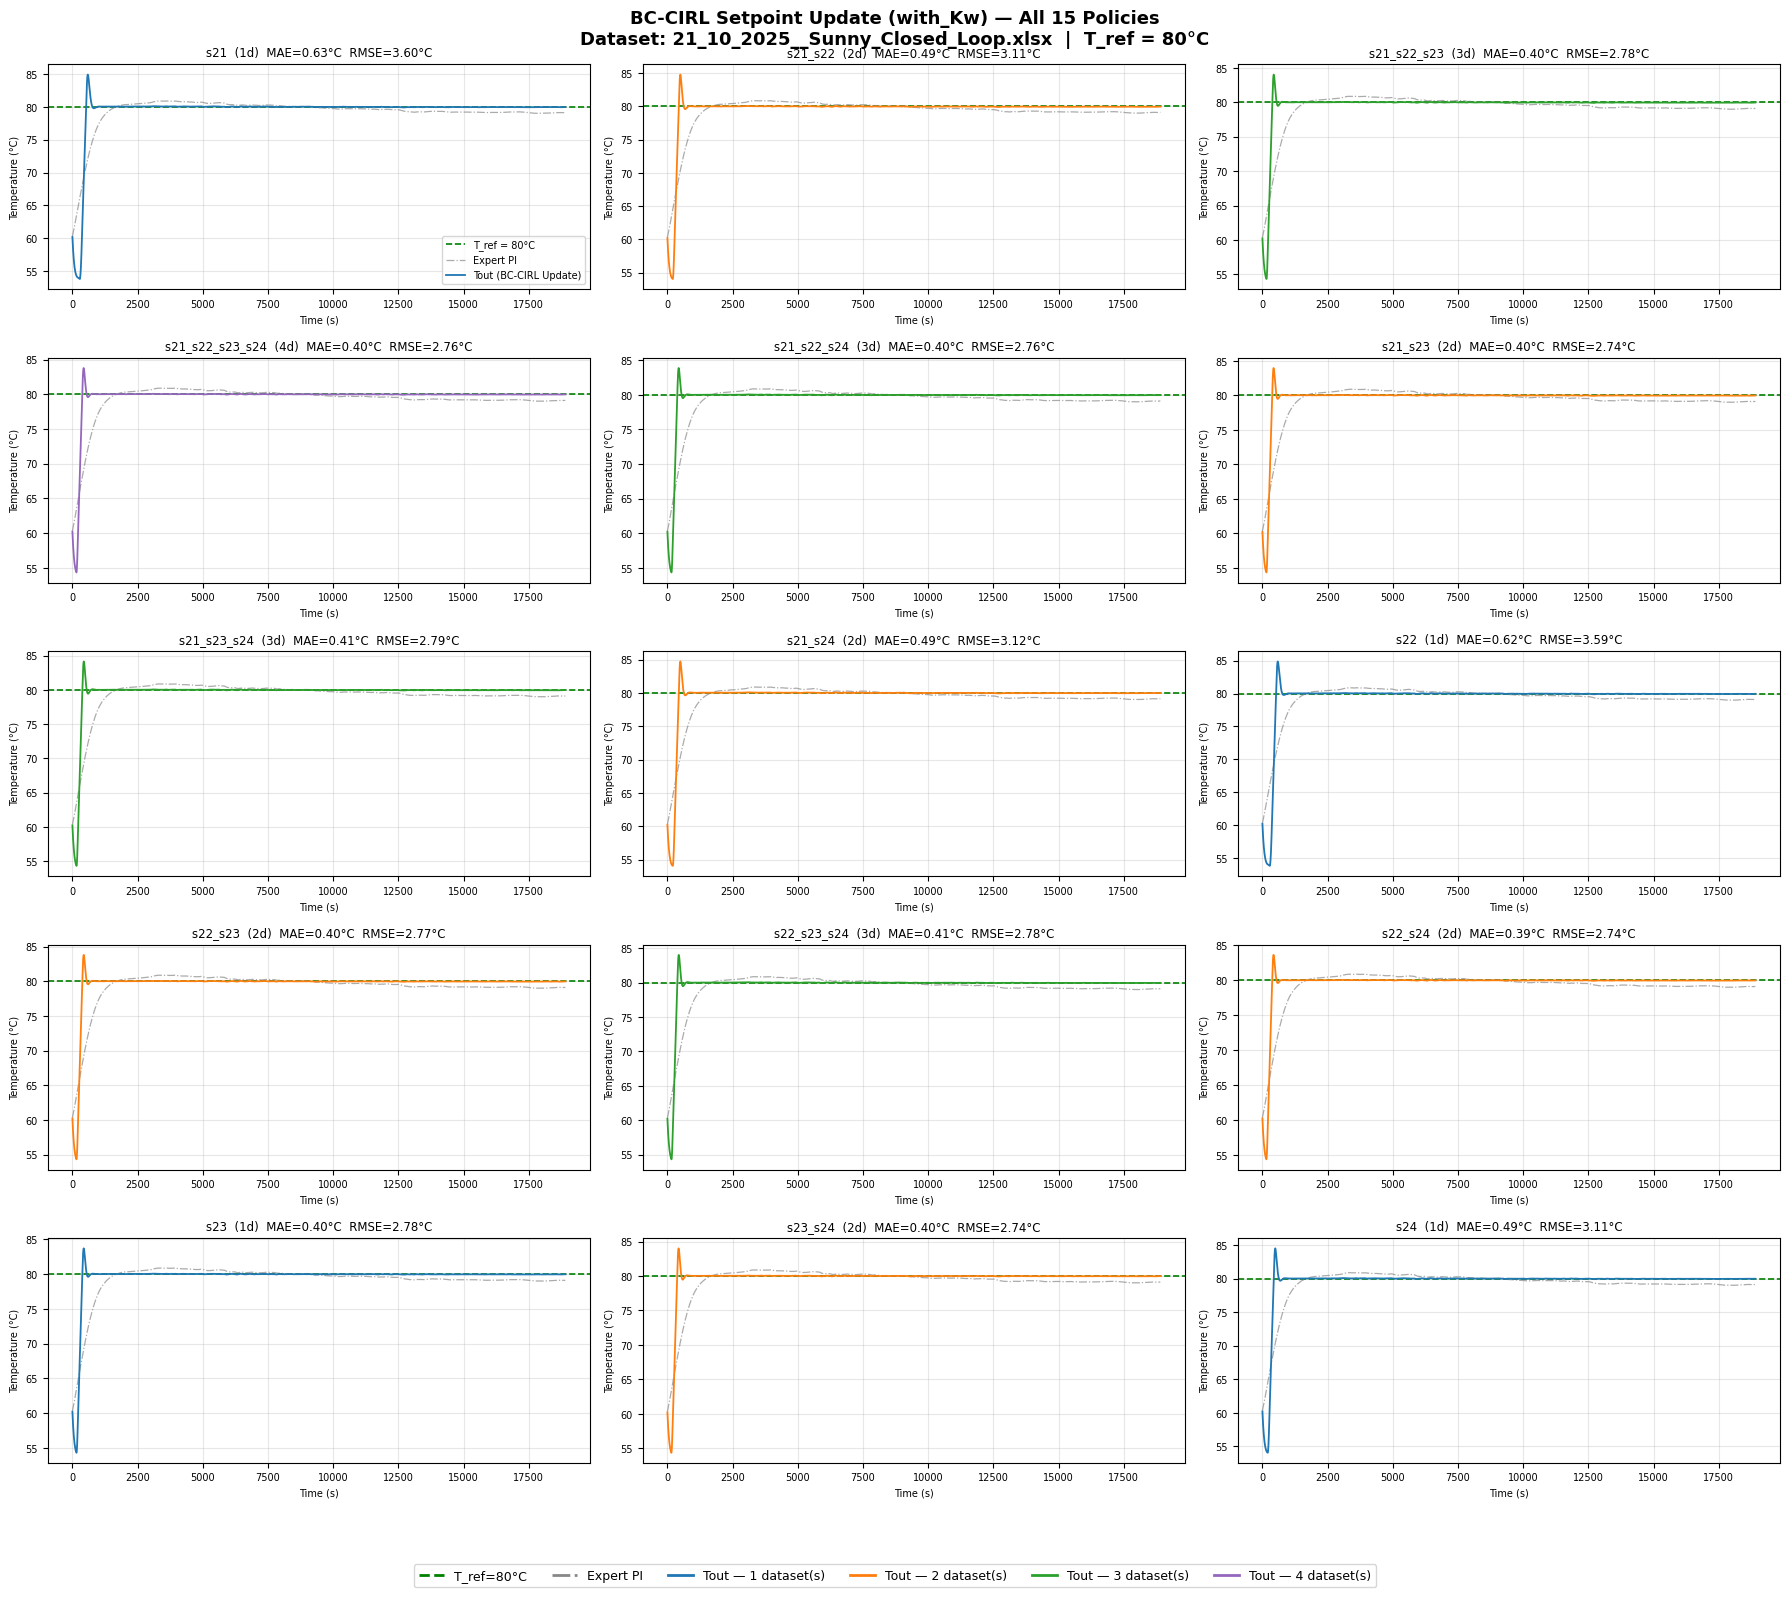

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\CQL Offline Actor\charts\cql_cirl_setpoint_anti_windup_grid_s21_80C.png


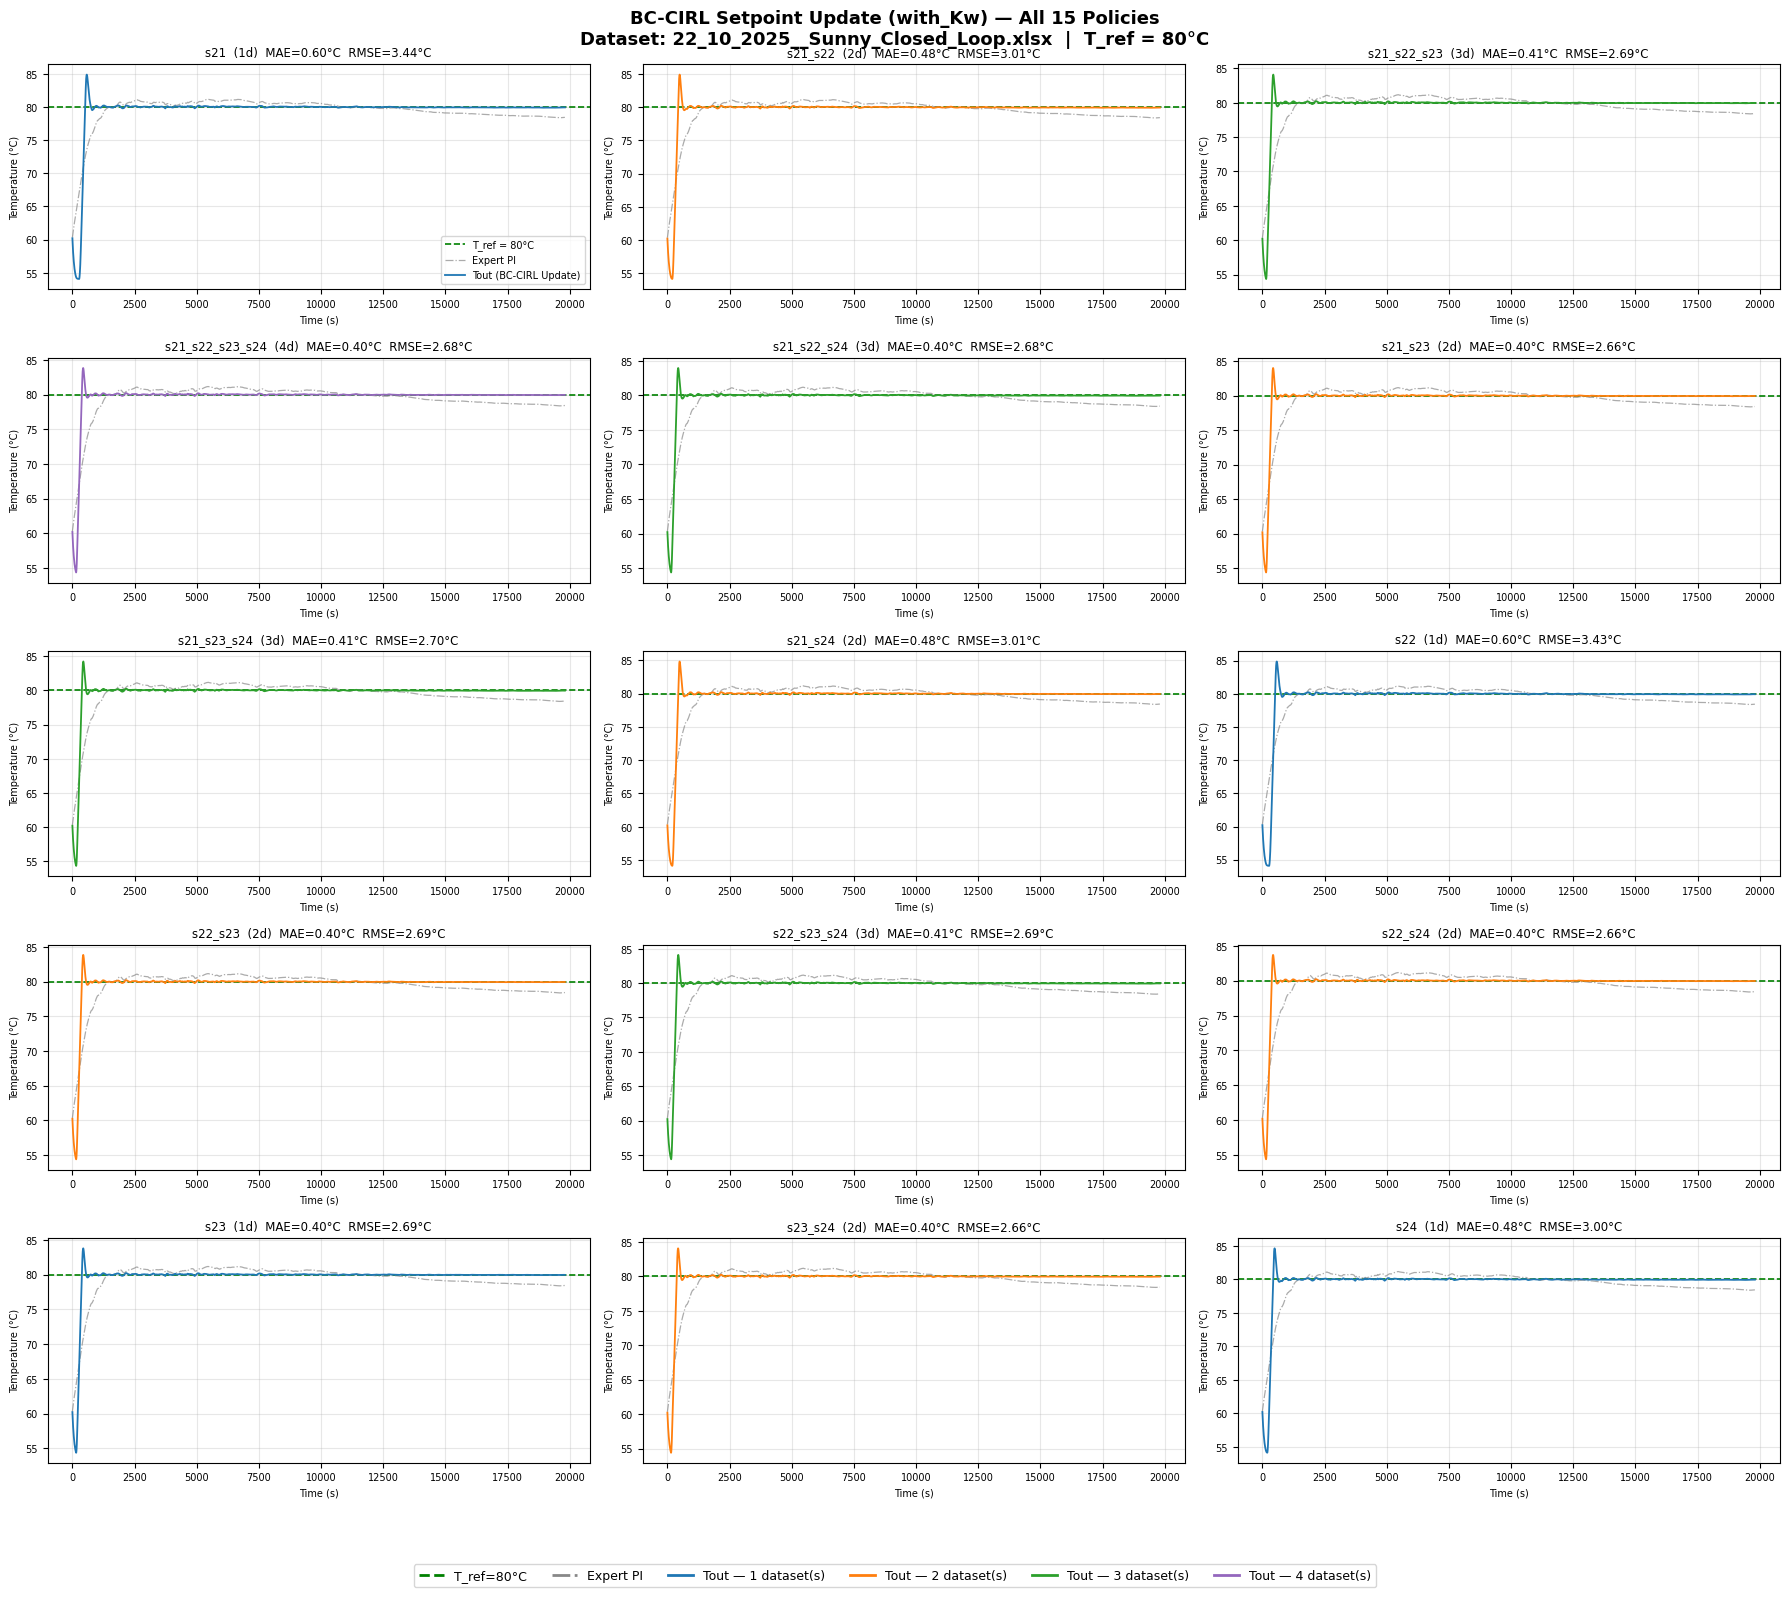

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\CQL Offline Actor\charts\cql_cirl_setpoint_anti_windup_grid_s22_80C.png


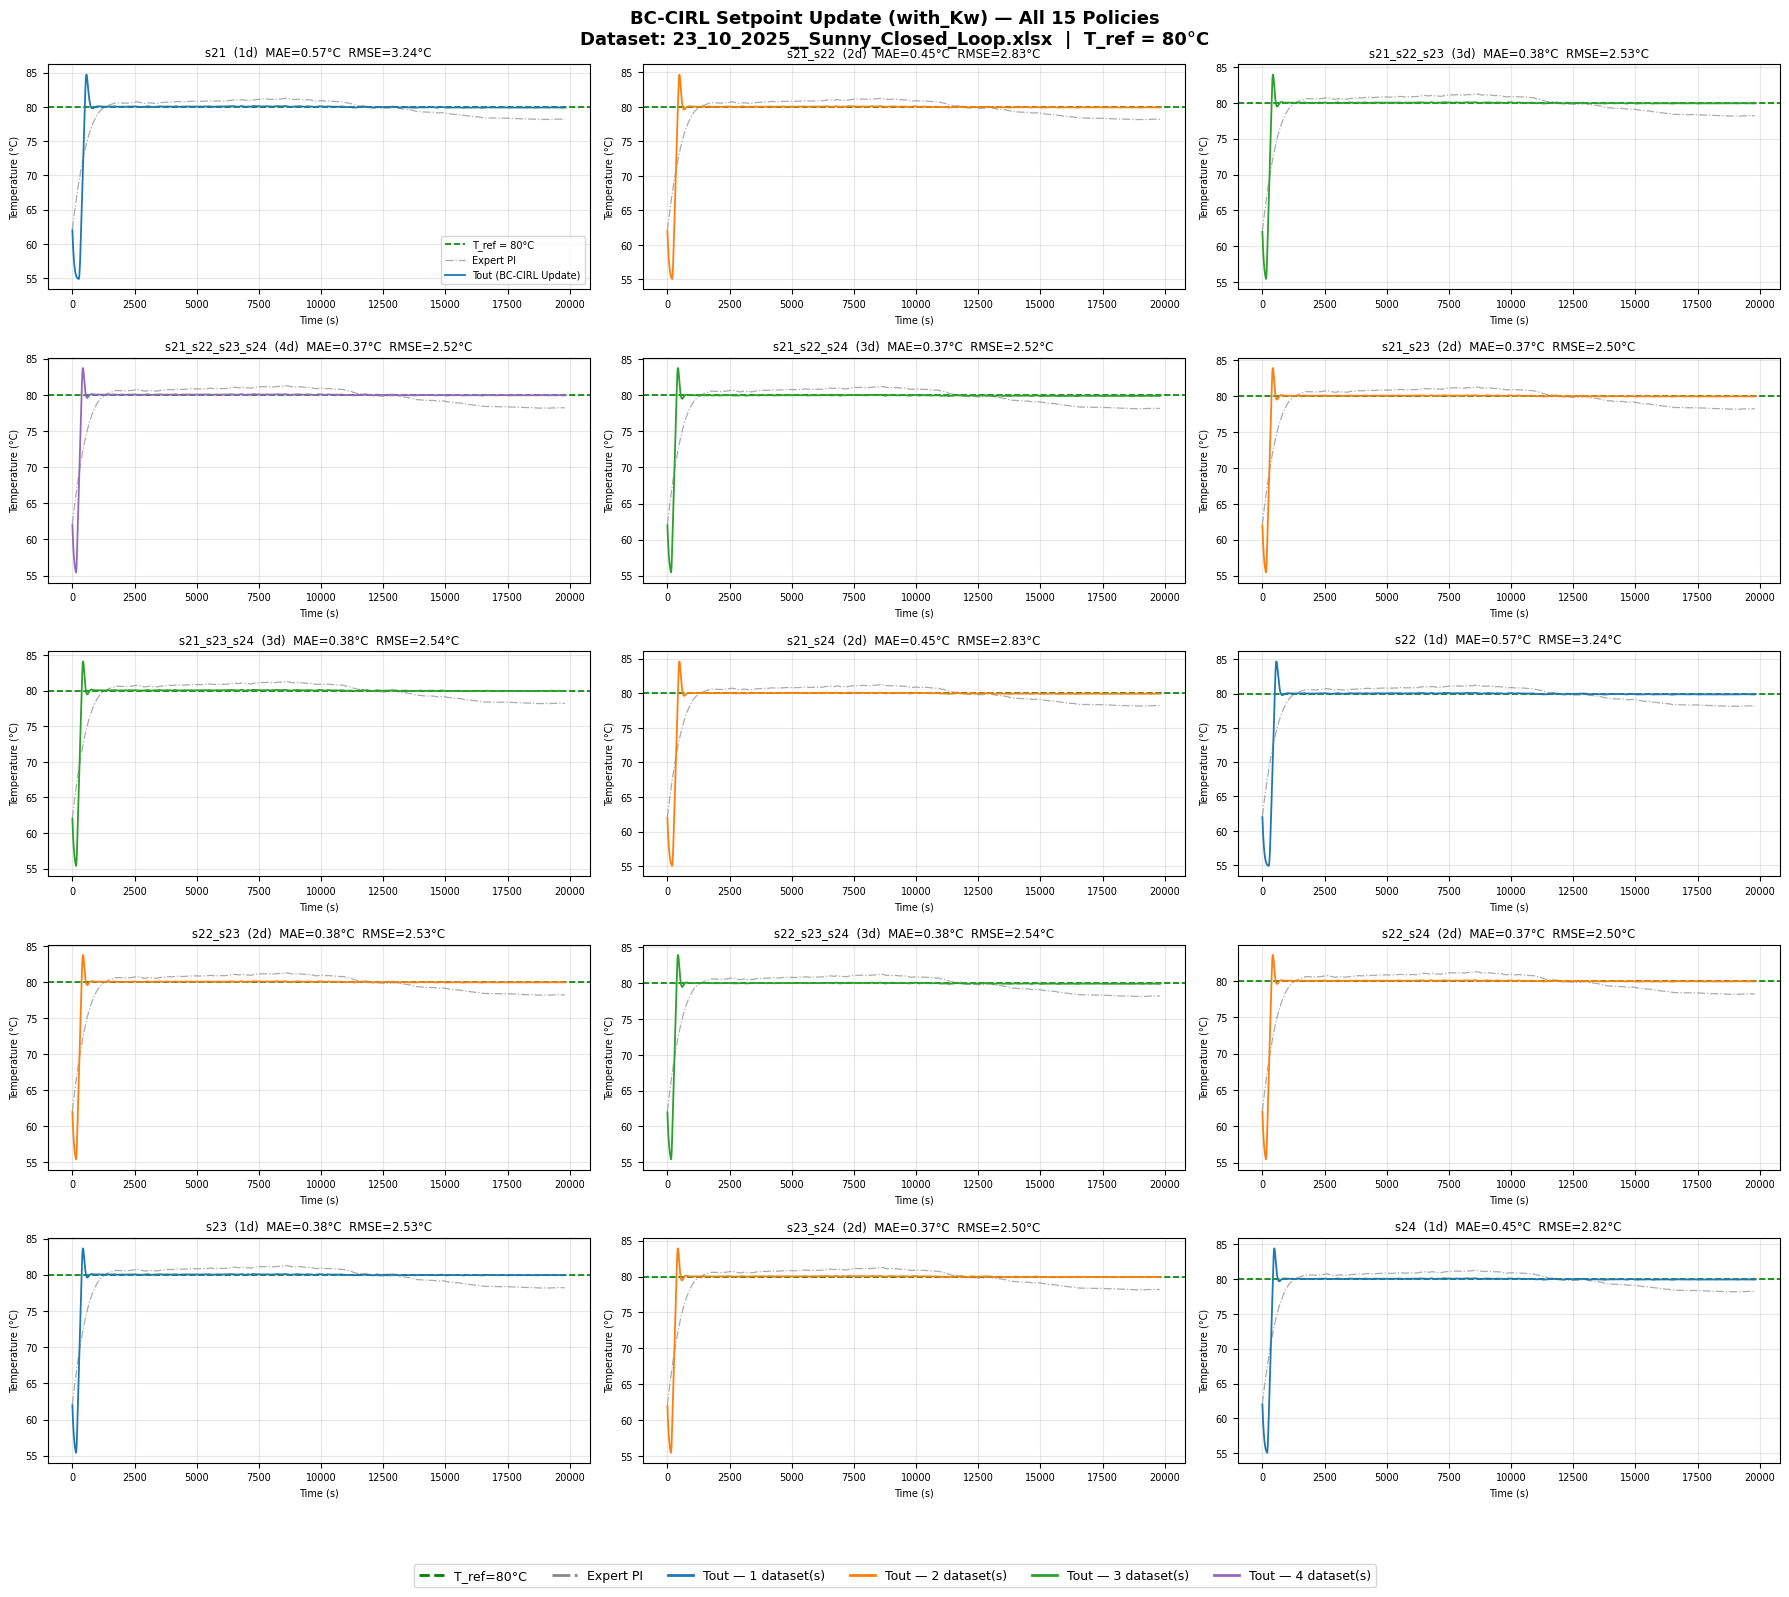

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\CQL Offline Actor\charts\cql_cirl_setpoint_anti_windup_grid_s23_80C.png


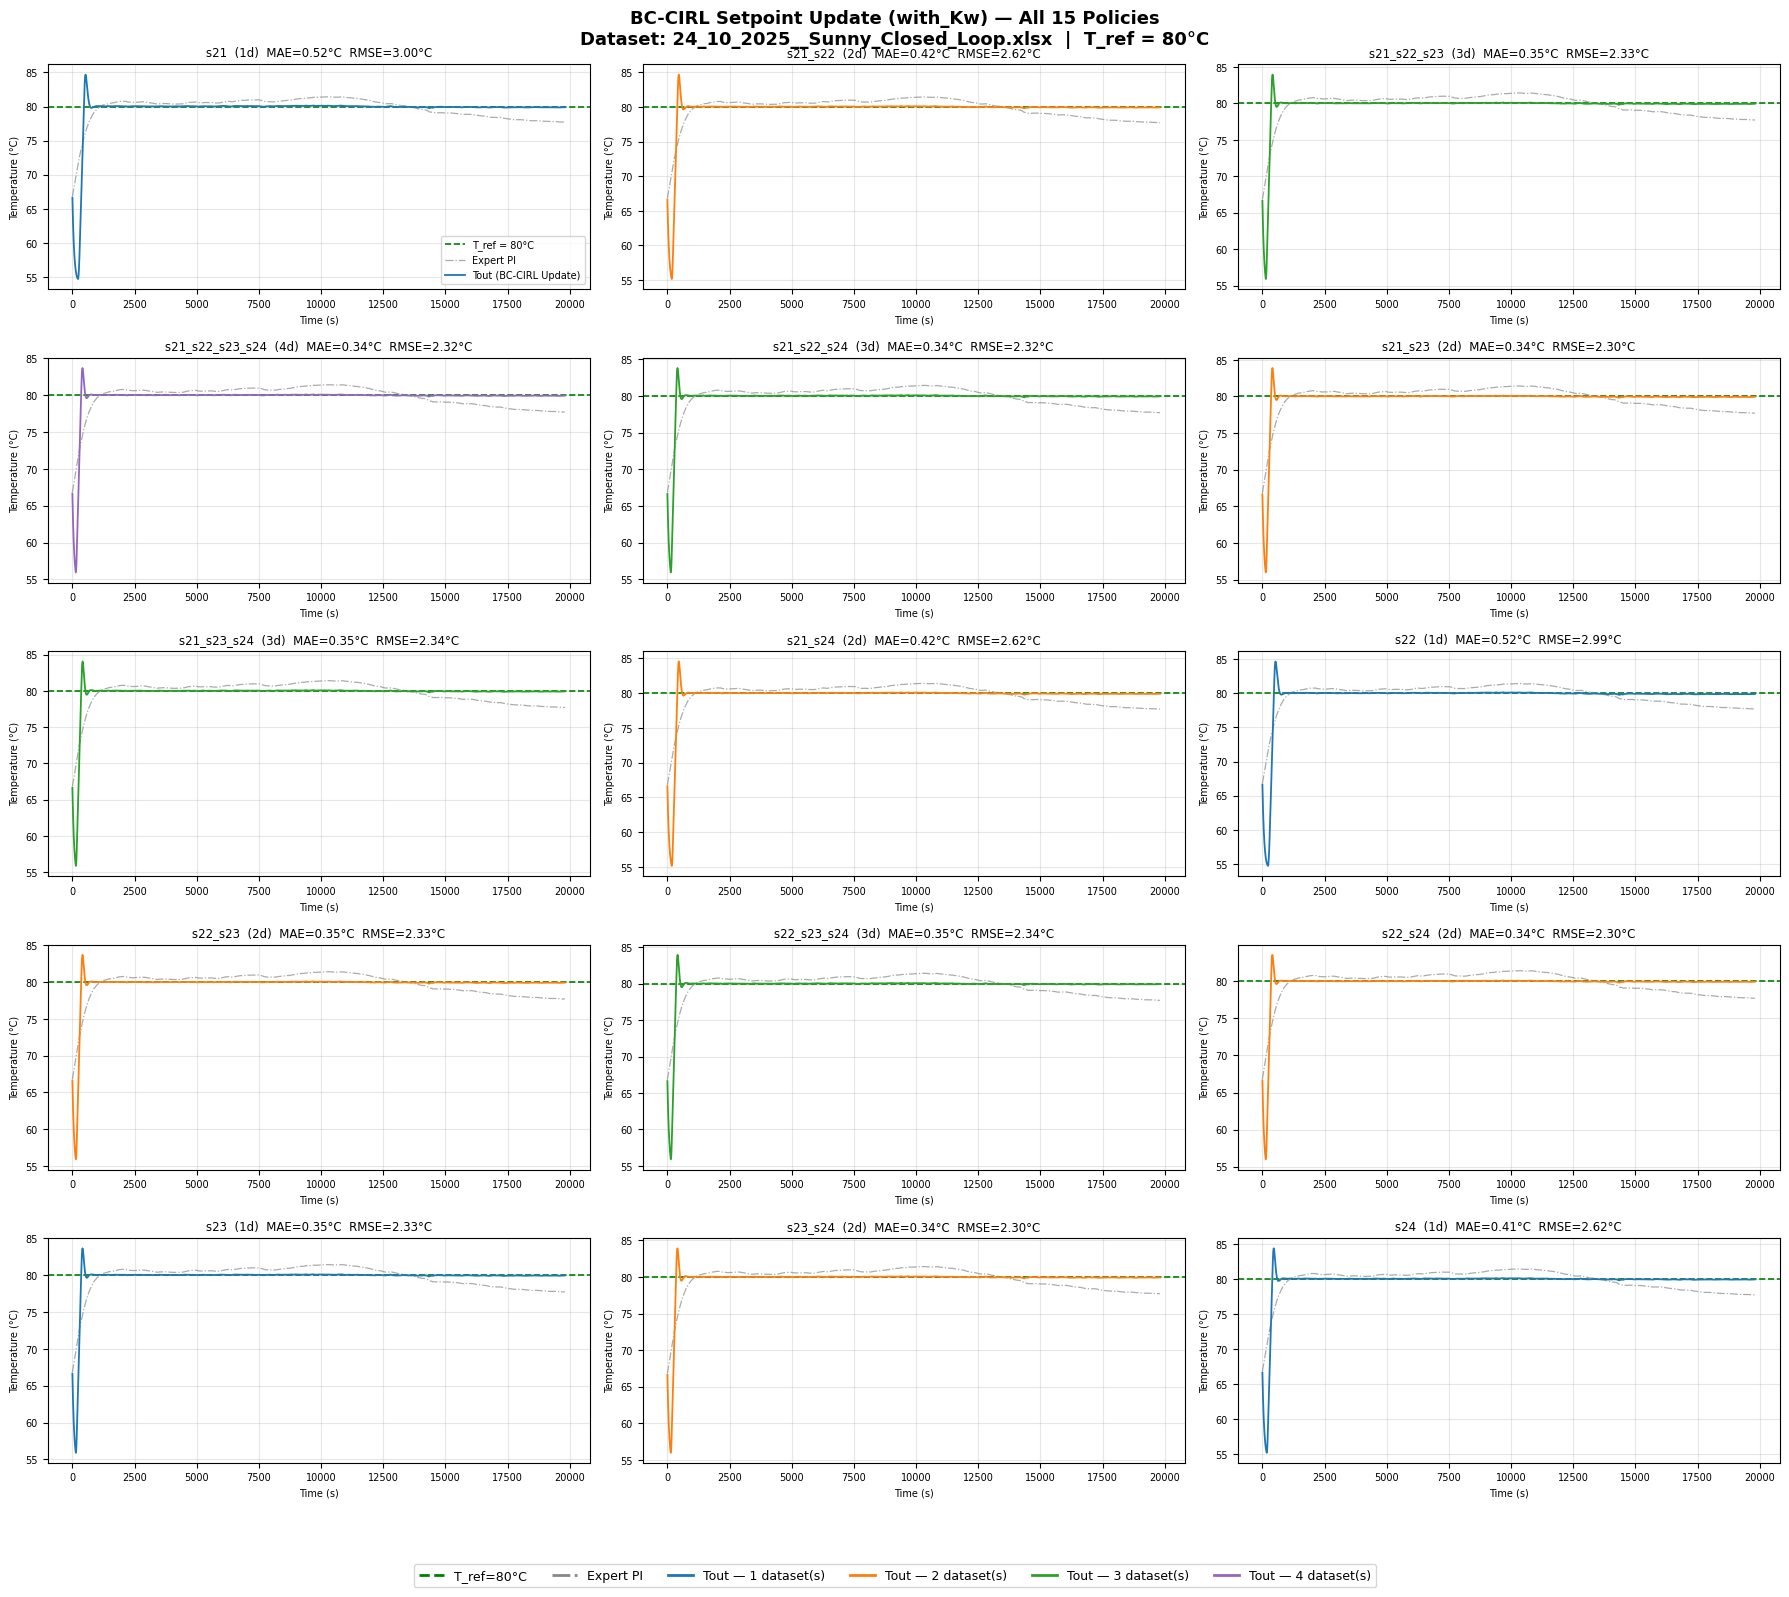

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\CQL Offline Actor\charts\cql_cirl_setpoint_anti_windup_grid_s24_80C.png


In [6]:
# ── All policies evaluated on each dataset individually (s20 → s24) ────────────
# Runs all rollouts once, then plots a separate 5×3 grid for each dataset.
ALL_DATASETS_5 = [
    "20_10_2025__Cloudy_Closed_Loop.xlsx",
    "21_10_2025__Sunny_Closed_Loop.xlsx",
    "22_10_2025__Sunny_Closed_Loop.xlsx",
    "23_10_2025__Sunny_Closed_Loop.xlsx",
    "24_10_2025__Sunny_Closed_Loop.xlsx",
]
DS_LABELS_5 = ["s20 (65°C)", "s21 (80°C)", "s22 (80°C)", "s23 (80°C)", "s24 (80°C)"]
DS_COLORS_5 = ["#b41f1f", "#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

# ── Run all rollouts ───────────────────────────────────────────────────────────
print("Running rollouts for all policies on all 5 datasets...")
print("  (T_ref auto-selected: cloudy→65°C, sunny→80°C)\n")
all_results_5 = {}
all_exp_5     = {}

for ds_file, ds_label in zip(ALL_DATASETS_5, DS_LABELS_5):
    ds_data = load_dataset(ds_file)
    Tout_pi, q_pi = rollout_expert(ds_data)
    all_exp_5[ds_label] = {
        'Tout': Tout_pi,
        'tref': dataset_tref(ds_file),
        'time': ds_data['time_ax'][1 : len(Tout_pi) + 1],
    }

for p in policies:
    combo = p['combo_name']
    all_results_5[combo] = {}
    for ds_file, ds_label in zip(ALL_DATASETS_5, DS_LABELS_5):
        ds_data = load_dataset(ds_file)
        tr = dataset_tref(ds_file)
        Tout, q, Kp_arr, Ki_arr, Kw_arr = \
            rollout_bc_cirl_setpoint_update(p['path'], ds_data)
        err = Tout - tr
        all_results_5[combo][ds_label] = {
            'Tout': Tout, 'error': err, 'tref': tr,
            'mae':  float(np.mean(np.abs(err))),
            'rmse': float(np.sqrt(np.mean(err ** 2))),
            'time': ds_data['time_ax'][1 : len(Tout) + 1],
        }
    avg_mae = np.mean([all_results_5[combo][lbl]['mae'] for lbl in DS_LABELS_5])
    print(f"  {combo:22s}  avg MAE={avg_mae:.3f}\u00b0C")

# Best-generalising policy: lowest MAE averaged across ALL 5 datasets
# (not just EVAL_DATASET) so "best" reflects generalisation.
avg_mae_all = {
    combo: float(np.mean([all_results_5[combo][lbl]['mae'] for lbl in DS_LABELS_5]))
    for combo in all_results_5
}
best_combo_all_ds = min(avg_mae_all, key=avg_mae_all.get)
print(f"\nBest-generalising policy (lowest avg MAE across all 5 datasets): "
      f"{best_combo_all_ds}  (avg MAE={avg_mae_all[best_combo_all_ds]:.4f}\u00b0C)")

print("\nAll rollouts done.")

# ── Per-dataset 5×3 grid ───────────────────────────────────────────────────────
n_cols = 3
n_rows = (len(policies) + n_cols - 1) // n_cols

for ds_file, ds_label, ds_color in zip(ALL_DATASETS_5, DS_LABELS_5, DS_COLORS_5):
    tr  = dataset_tref(ds_file)
    exp = all_exp_5[ds_label]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2), sharex=False)
    axes = axes.flatten()

    for idx, p in enumerate(policies):
        combo = p['combo_name']
        ax    = axes[idx]
        r     = all_results_5[combo][ds_label]
        t     = r['time']

        ax.axhline(tr, color='green', linewidth=1.2, linestyle='--',
                   label=f'T_ref = {tr:.0f}°C')
        ax.plot(t, exp['Tout'][:len(r['Tout'])],
                color='#888888', linewidth=0.9, linestyle='-.', alpha=0.7,
                label='Expert PI')
        ax.plot(t, r['Tout'],
                color=GROUP_COLORS.get(p['n_files'], '#333333'), linewidth=1.3,
                label='Tout (BC-CIRL Update)')
        ax.set_title(
            f"{combo}  ({p['n_files']}d)"
            f"  MAE={r['mae']:.2f}°C  RMSE={r['rmse']:.2f}°C",
            fontsize=8.5,
        )
        ax.set_ylabel('Temperature (°C)', fontsize=7)
        ax.set_xlabel('Time (s)', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=7, loc='best')

    for ax in axes[len(policies):]:
        ax.set_visible(False)

    from matplotlib.lines import Line2D
    color_handles = [
        Line2D([0],[0], color=GROUP_COLORS[n], linewidth=2, label=f'Tout — {n} dataset(s)')
        for n in sorted(GROUP_COLORS)
    ]
    type_handles = [
        Line2D([0],[0], color='green',   linewidth=2, linestyle='--', label=f'T_ref={tr:.0f}°C'),
        Line2D([0],[0], color='#888888', linewidth=2, linestyle='-.', label='Expert PI'),
    ]
    fig.legend(handles=type_handles + color_handles,
               loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(
        f'BC-CIRL Setpoint Update (with_Kw) — All {len(policies)} Policies\n'
        f'Dataset: {ds_file}  |  T_ref = {tr:.0f}°C',
        fontsize=13, fontweight='bold',
    )
    fig.tight_layout(rect=[0, 0.04, 1, 1])

    safe_label = ds_label.replace(' ', '_').replace('(', '').replace(')', '').replace('°', '')
    out = os.path.join(CHART_DIR, f'cql_cirl_setpoint_anti_windup_grid_{safe_label}.png')
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out}")

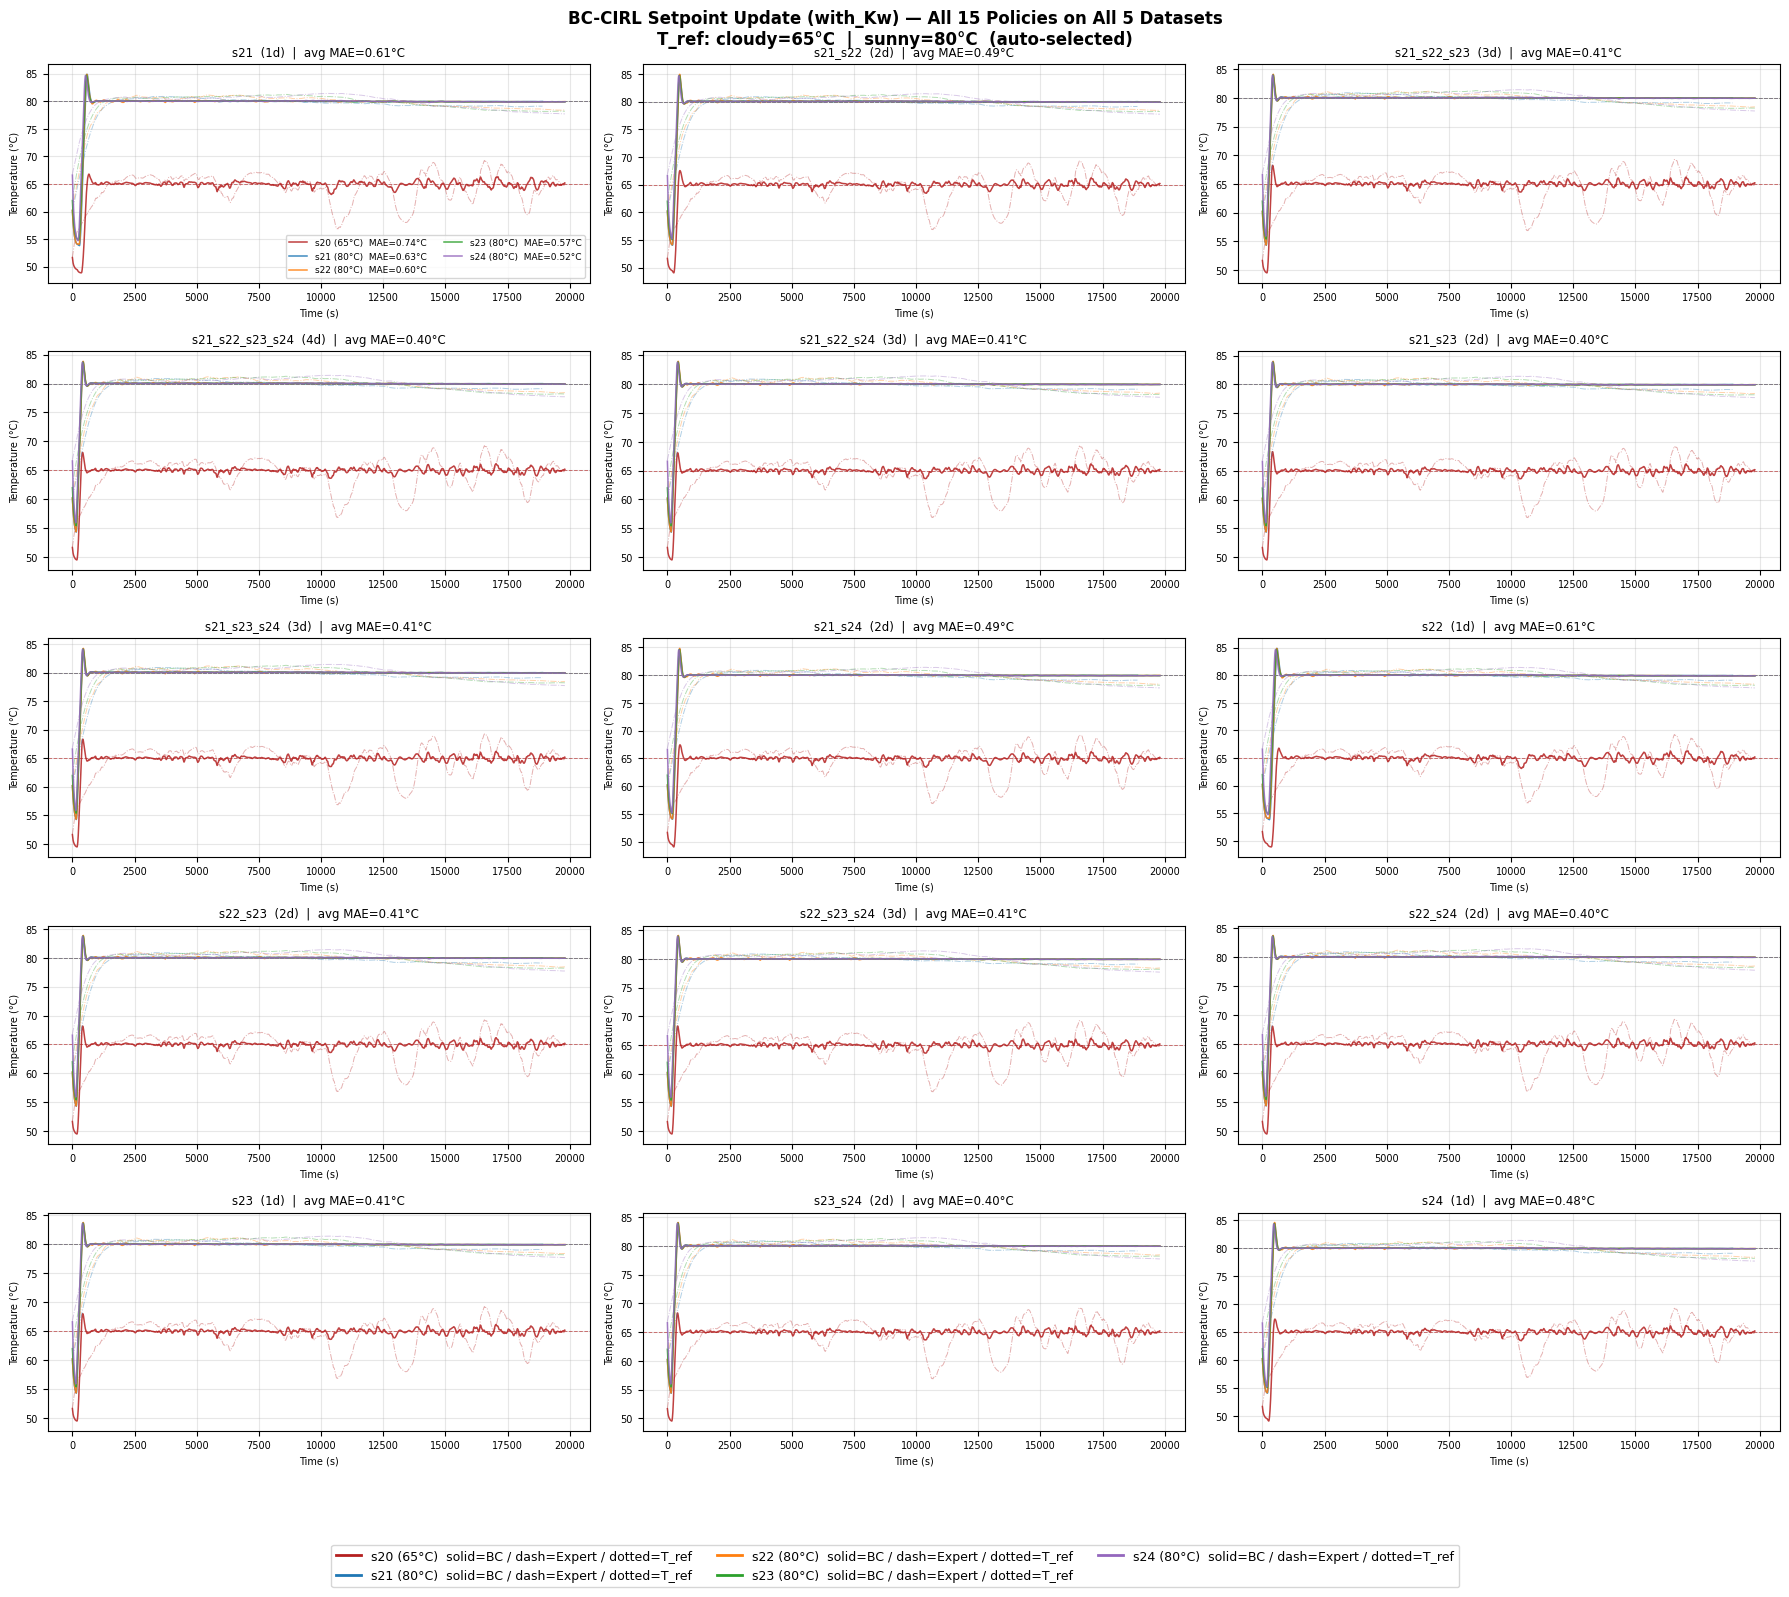

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\CQL Offline Actor\charts\cql_cirl_setpoint_anti_windup_all_policies_all_datasets.png


In [7]:
# ── 5×3 grid: all policies — each subplot shows all 5 datasets overlaid ────────
# Uses all_results_5 / all_exp_5 from the cell above — no re-run needed.
n_cols = 3
n_rows = (len(policies) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2), sharex=False)
axes = axes.flatten()

for idx, p in enumerate(policies):
    combo = p['combo_name']
    ax    = axes[idx]

    mae_list = []
    for ds_label, ds_color in zip(DS_LABELS_5, DS_COLORS_5):
        r  = all_results_5[combo][ds_label]
        t  = r['time']
        tr = r['tref']

        ax.axhline(tr, color=ds_color, linewidth=0.7, linestyle='--', alpha=0.6)
        ax.plot(all_exp_5[ds_label]['time'][:len(r['Tout'])],
                all_exp_5[ds_label]['Tout'][:len(r['Tout'])],
                color=ds_color, linewidth=0.7, linestyle='-.', alpha=0.35)
        ax.plot(t, r['Tout'],
                color=ds_color, linewidth=1.1, alpha=0.85,
                label=f'{ds_label}  MAE={r["mae"]:.2f}°C')
        mae_list.append(r['mae'])

    avg_mae = float(np.mean(mae_list))
    ax.set_title(
        f"{combo}  ({p['n_files']}d)  |  avg MAE={avg_mae:.2f}°C",
        fontsize=8.5,
    )
    ax.set_ylabel('Temperature (°C)', fontsize=7)
    ax.set_xlabel('Time (s)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=6.5, loc='best', ncol=2)

for ax in axes[len(policies):]:
    ax.set_visible(False)

from matplotlib.lines import Line2D
ds_handles = [
    Line2D([0],[0], color=DS_COLORS_5[i], linewidth=2,
           label=f'{DS_LABELS_5[i]}  solid=BC / dash=Expert / dotted=T_ref')
    for i in range(len(DS_LABELS_5))
]
fig.legend(handles=ds_handles,
           loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    f'BC-CIRL Setpoint Update (with_Kw) — All {len(policies)} Policies on All 5 Datasets\n'
    f'T_ref: cloudy=65°C  |  sunny=80°C  (auto-selected)',
    fontsize=12, fontweight='bold',
)
fig.tight_layout(rect=[0, 0.06, 1, 1])

out = os.path.join(CHART_DIR, 'cql_cirl_setpoint_anti_windup_all_policies_all_datasets.png')
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")

In [8]:
# ── Summary table ──────────────────────────────────────────────────────────────
best_combo = best_combo_all_ds  # best-generalising policy (avg MAE across all 5 datasets)
ds_type    = 'cloudy' if TREF == TREF_CLOUDY else 'sunny'

print(f"Evaluated on: {EVAL_DATASET}  |  T_ref = {TREF}°C ({ds_type})  [with_Kw]\n")
print(f"{'#':>3}  {'Combo':>22}  {'N':>1}  {'MAE (°C)':>10}  "
      f"{'RMSE (°C)':>11}  {'Max |e| (°C)':>13}  "
      f"{'Kp_mean':>8}  {'Ki_mean':>9}  {'Kw_mean':>8}")
print('-' * 100)
for i, p in enumerate(policies, 1):
    combo = p['combo_name']
    if combo not in results:
        continue
    r      = results[combo]
    marker = '  <- best' if combo == best_combo else ''
    print(f"  {i:>2}  {combo:>22}  {p['n_files']:>1}"
          f"  {r['mae']:>10.4f}  {r['rmse']:>11.4f}  {r['max_e']:>13.4f}"
          f"  {r['Kp_mean']:>8.4f}  {r['Ki_mean']:>9.5f}  {r['Kw_mean']:>8.4f}{marker}")

exp_mae  = float(np.mean(np.abs(err_exp)))
exp_rmse = float(np.sqrt(np.mean(err_exp**2)))
print(f"\nExpert PI baseline  MAE={exp_mae:.4f}°C  RMSE={exp_rmse:.4f}°C  (T_ref={TREF}°C)")
print(f"\nBest 'with_Kw' policy: {best_combo}")
print(f"  MAE     = {results[best_combo]['mae']:.4f} °C")
print(f"  RMSE    = {results[best_combo]['rmse']:.4f} °C")
print(f"  Kp_mean = {results[best_combo]['Kp_mean']:.4f}")
print(f"  Ki_mean = {results[best_combo]['Ki_mean']:.5f}")
print(f"  Kw_mean = {results[best_combo]['Kw_mean']:.4f}  (= Ki/Kp, pinned)")

Evaluated on: 20_10_2025__Cloudy_Closed_Loop.xlsx  |  T_ref = 65.0°C (cloudy)  [with_Kw]

  #                   Combo  N    MAE (°C)    RMSE (°C)   Max |e| (°C)   Kp_mean    Ki_mean   Kw_mean
----------------------------------------------------------------------------------------------------
   1                     s21  1      0.7439       2.4298        16.1186   -1.8155   -0.02896   -0.1554
   2                 s21_s22  2      0.5956       2.0629        15.9473   -1.8951   -0.03778   -0.2313
   3             s21_s22_s23  3      0.5121       1.7811        15.4945   -1.8153   -0.04464   -0.3413
   4         s21_s22_s23_s24  4      0.5018       1.7659        15.4870   -1.8918   -0.04511   -0.3424
   5             s21_s22_s24  3      0.5064       1.7759        15.4923   -1.8728   -0.04480   -0.3414
   6                 s21_s23  2      0.5037       1.7609        15.4842   -1.7906   -0.04609   -0.3418
   7             s21_s23_s24  3      0.5223       1.7978        15.5042   -1.7436   -0.04

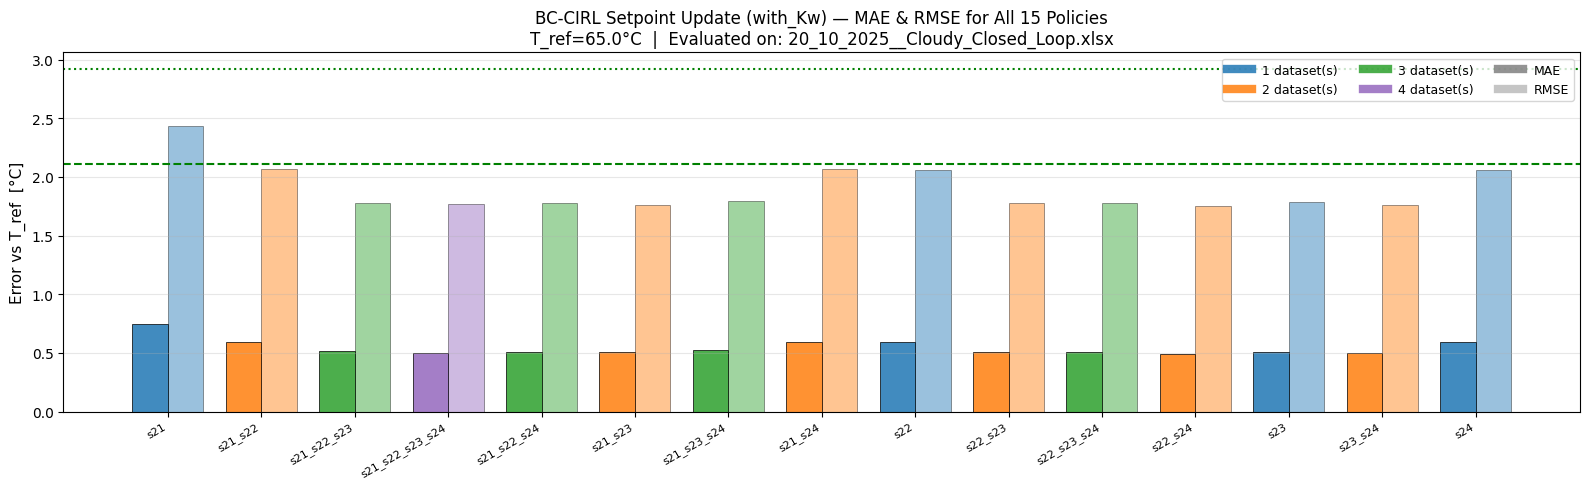

Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\CQL Offline Actor\charts\cql_cirl_setpoint_anti_windup_mae_rmse_bars_20_10_2025.png


In [9]:
# ── MAE & RMSE bar chart — all policies + Expert PI reference ──────────────────
combos = [p['combo_name'] for p in policies if p['combo_name'] in results]
maes   = [results[c]['mae']  for c in combos]
rmses  = [results[c]['rmse'] for c in combos]
colors = [GROUP_COLORS.get(results[c]['n_files'], '#333333') for c in combos]

x = np.arange(len(combos))
w = 0.38

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w/2, maes,  width=w, color=colors, alpha=0.85,
       edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, rmses, width=w, color=colors, alpha=0.45,
       edgecolor='black', linewidth=0.6)

exp_mae  = float(np.mean(np.abs(err_exp)))
exp_rmse = float(np.sqrt(np.mean(err_exp ** 2)))
ax.axhline(exp_mae,  color='green', linewidth=1.5, linestyle='--',
           label=f'Expert PI MAE={exp_mae:.3f}°C')
ax.axhline(exp_rmse, color='green', linewidth=1.5, linestyle=':',
           label=f'Expert PI RMSE={exp_rmse:.3f}°C')

ax.set_xticks(x)
ax.set_xticklabels(combos, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Error vs T_ref  [°C]', fontsize=11)
ax.set_title(
    f'BC-CIRL Setpoint Update (with_Kw) — MAE & RMSE for All {len(policies)} Policies\n'
    f'T_ref={TREF}°C  |  Evaluated on: {EVAL_DATASET}',
    fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

from matplotlib.lines import Line2D
color_handles = [
    Line2D([0],[0], color=GROUP_COLORS[n], linewidth=6,
           alpha=0.85, label=f'{n} dataset(s)')
    for n in sorted(GROUP_COLORS)
]
type_handles = [
    Line2D([0],[0], color='grey', linewidth=6, alpha=0.85, label='MAE'),
    Line2D([0],[0], color='grey', linewidth=6, alpha=0.45, label='RMSE'),
]
ax.legend(handles=color_handles + type_handles, fontsize=9,
          loc='upper right', ncol=3)

fig.tight_layout()
out = os.path.join(CHART_DIR, f'cql_cirl_setpoint_anti_windup_mae_rmse_bars_{EVAL_LABEL}.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out}")

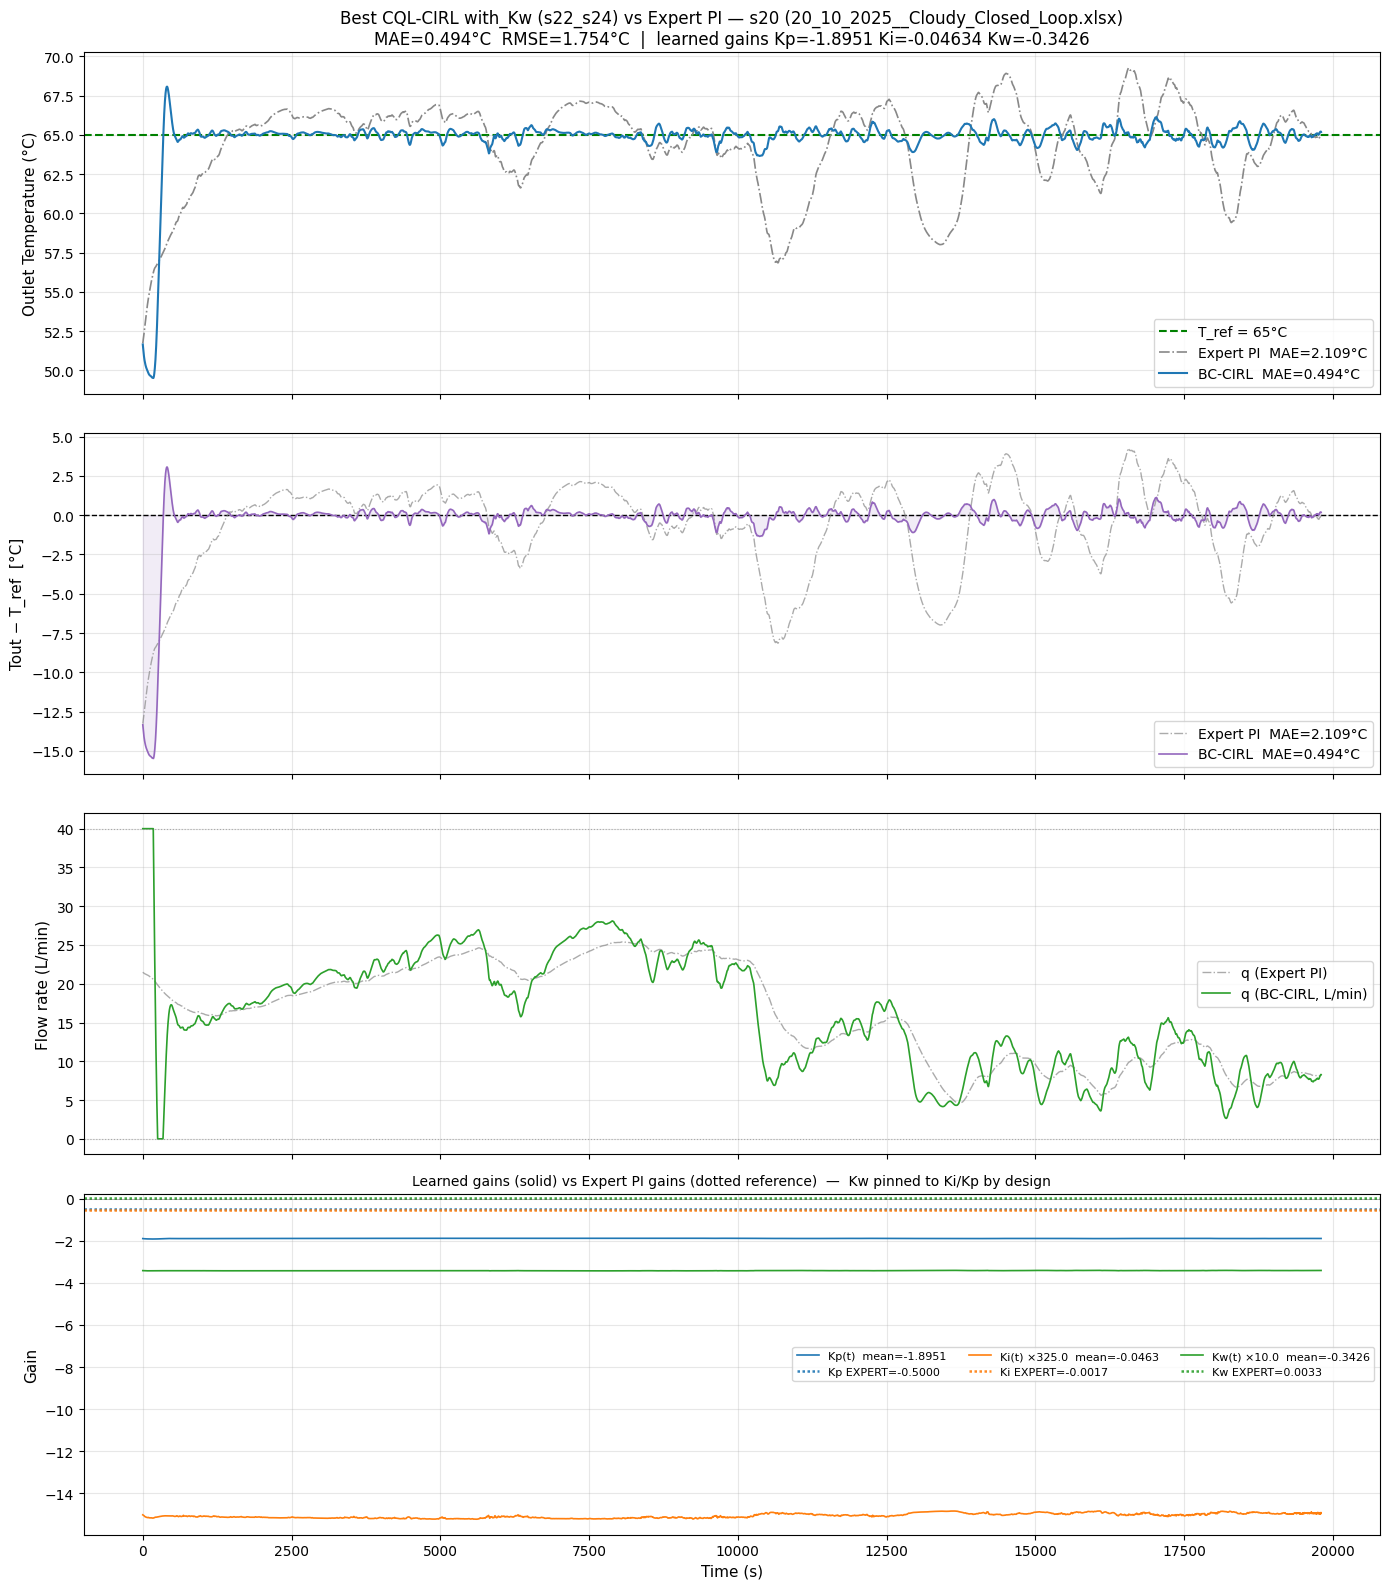

s20 (20_10_2025__Cloudy_Closed_Loop.xlsx)  BC-CIRL MAE=0.494  Expert MAE=2.109  | learned Kp=-1.8951 Ki=-0.04634  vs  expert Kp=-0.5000 Ki=-0.00167


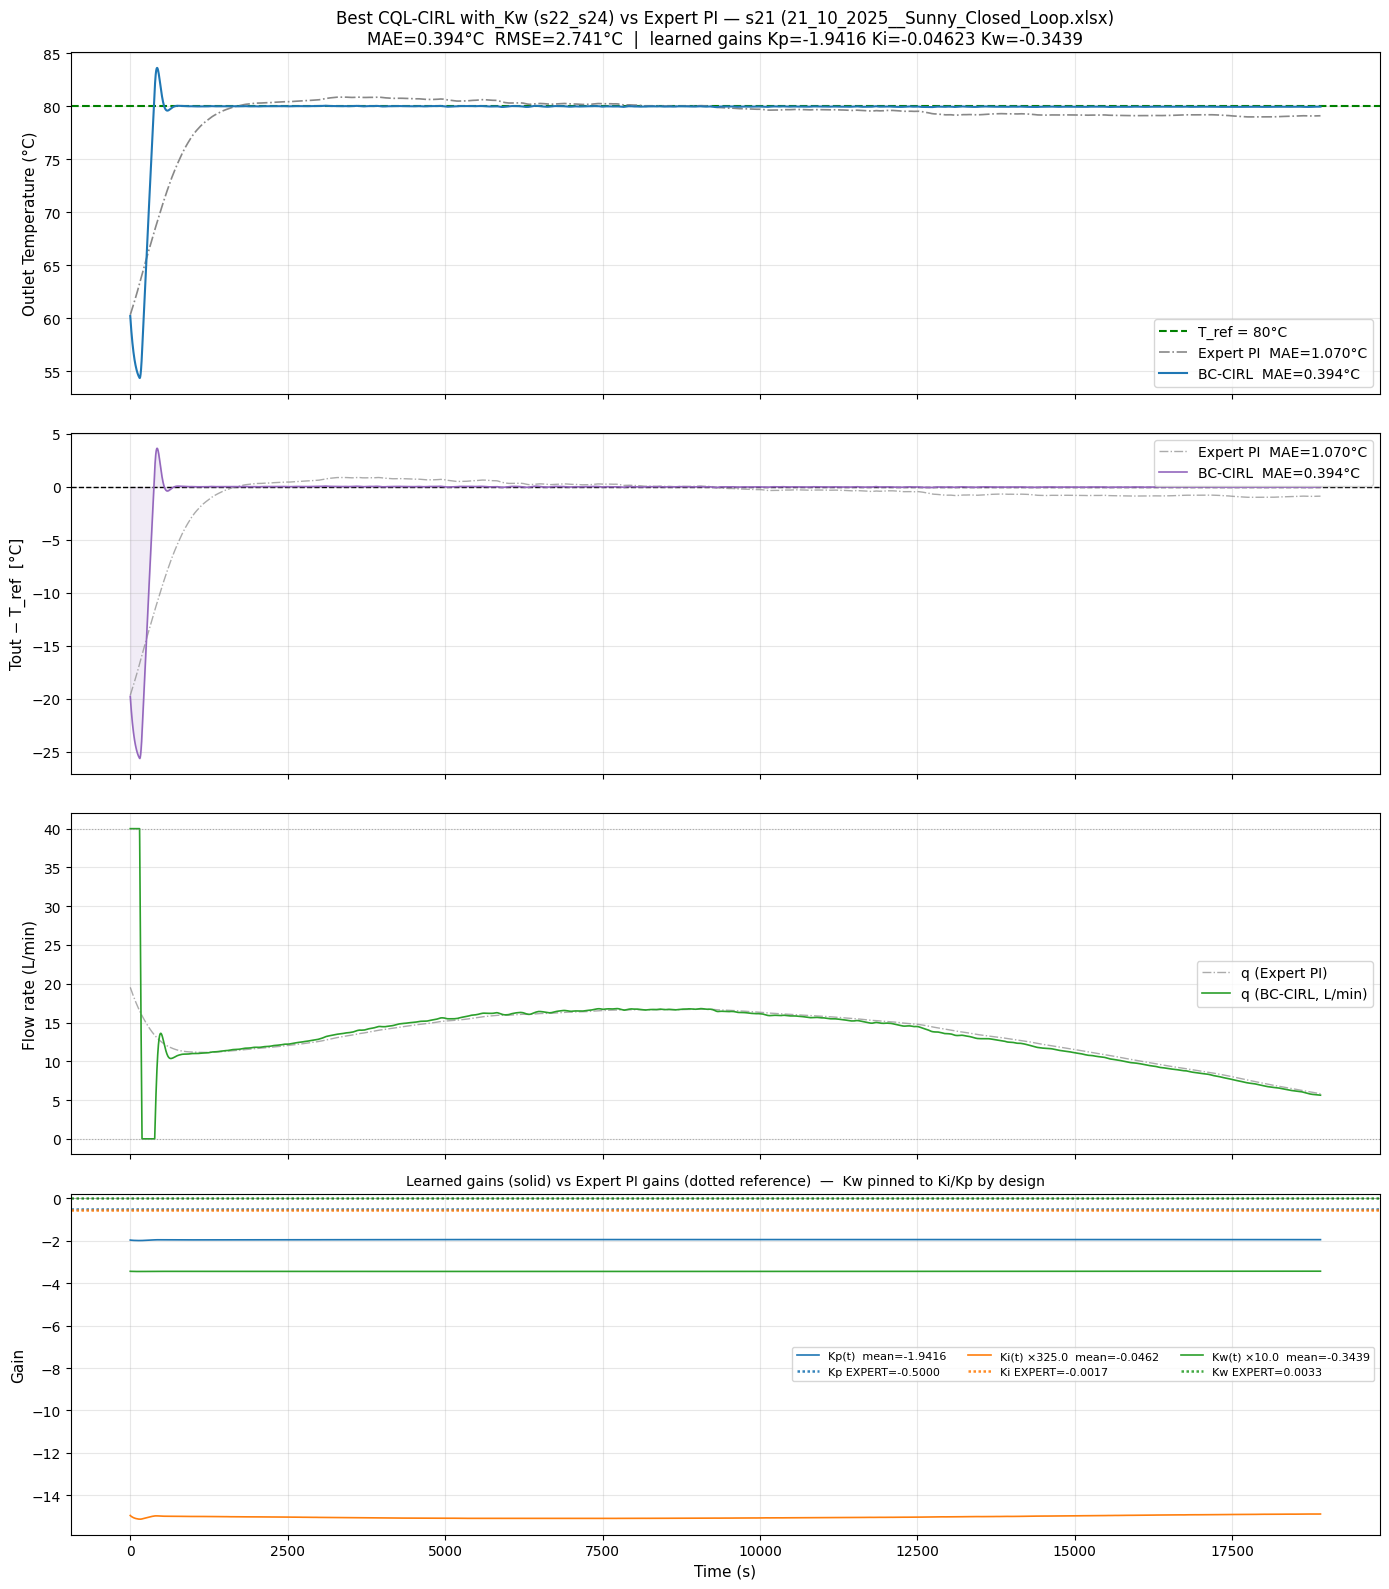

s21 (21_10_2025__Sunny_Closed_Loop.xlsx)  BC-CIRL MAE=0.394  Expert MAE=1.070  | learned Kp=-1.9416 Ki=-0.04623  vs  expert Kp=-0.5000 Ki=-0.00167


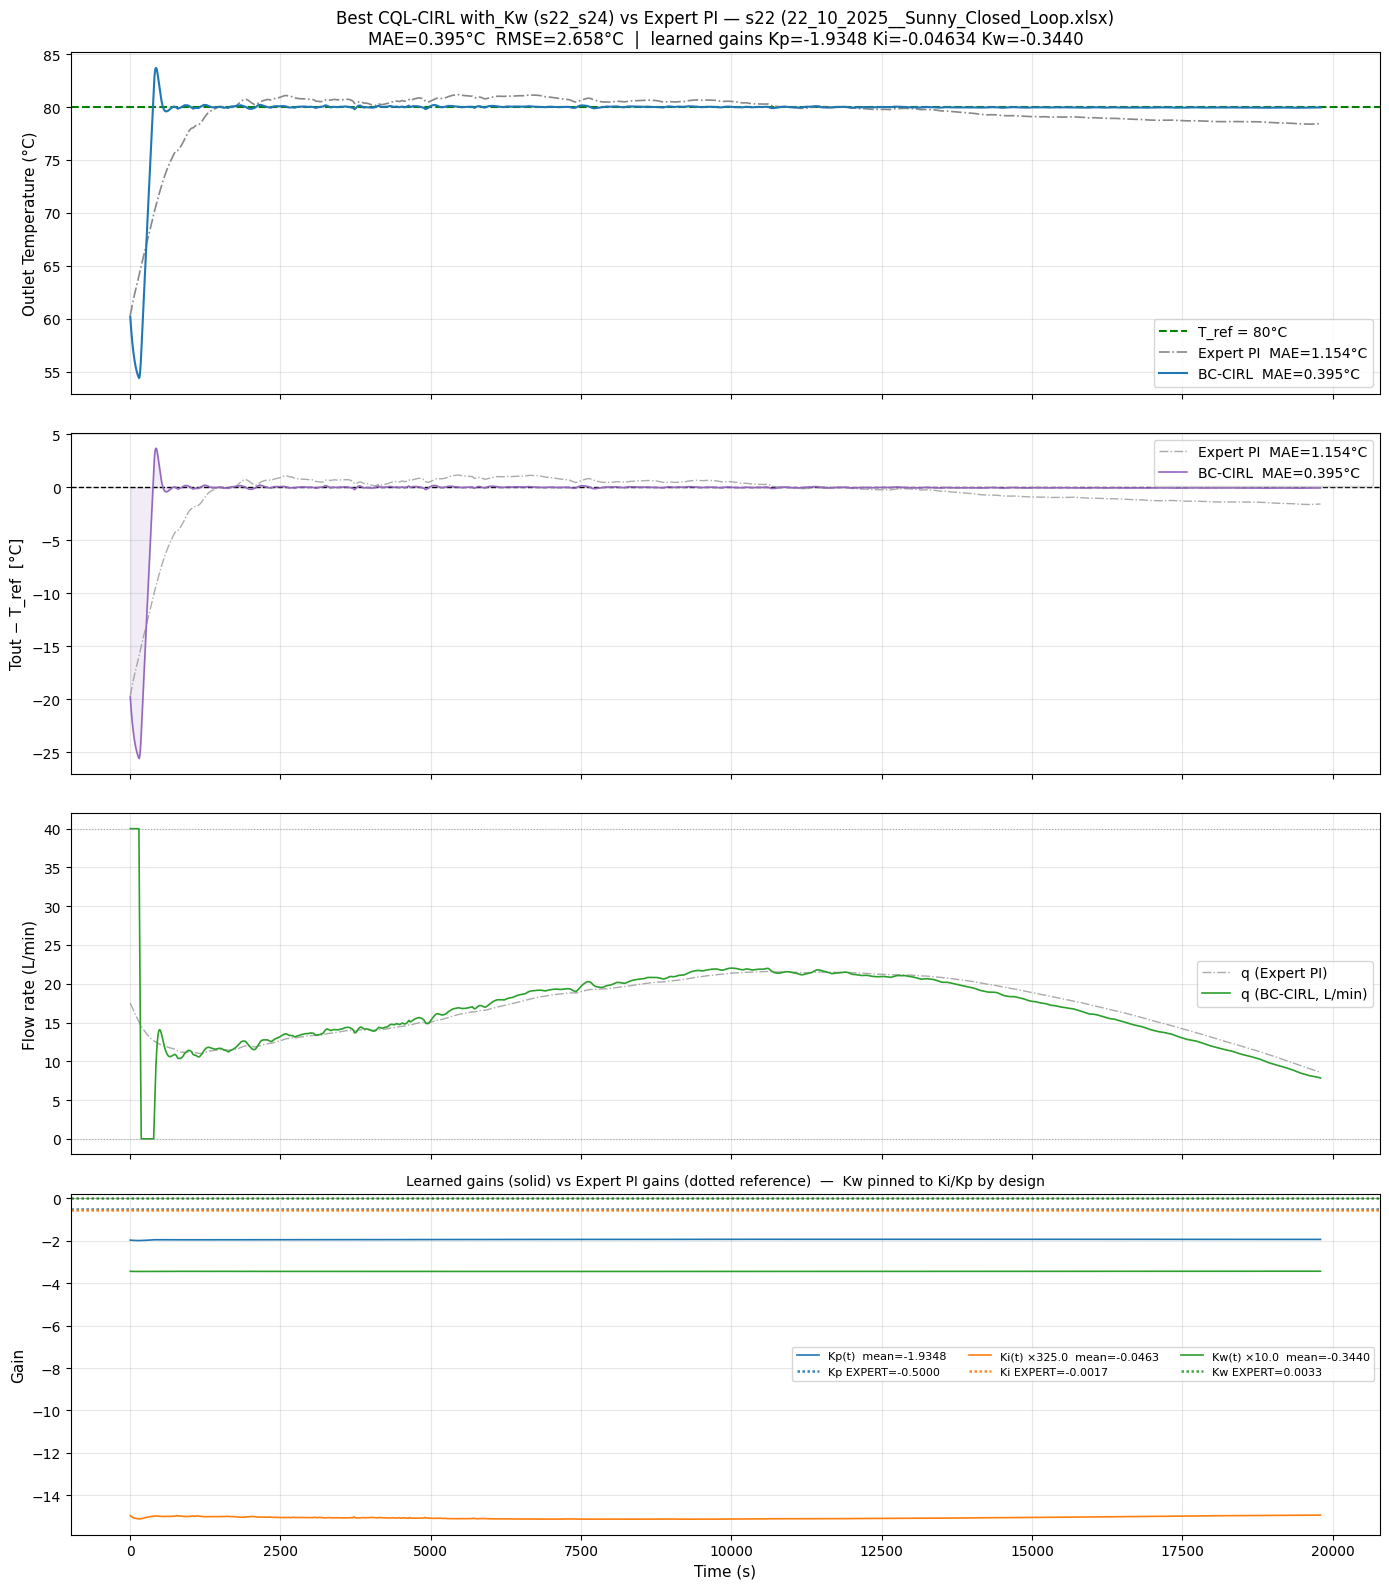

s22 (22_10_2025__Sunny_Closed_Loop.xlsx)  BC-CIRL MAE=0.395  Expert MAE=1.154  | learned Kp=-1.9348 Ki=-0.04634  vs  expert Kp=-0.5000 Ki=-0.00167


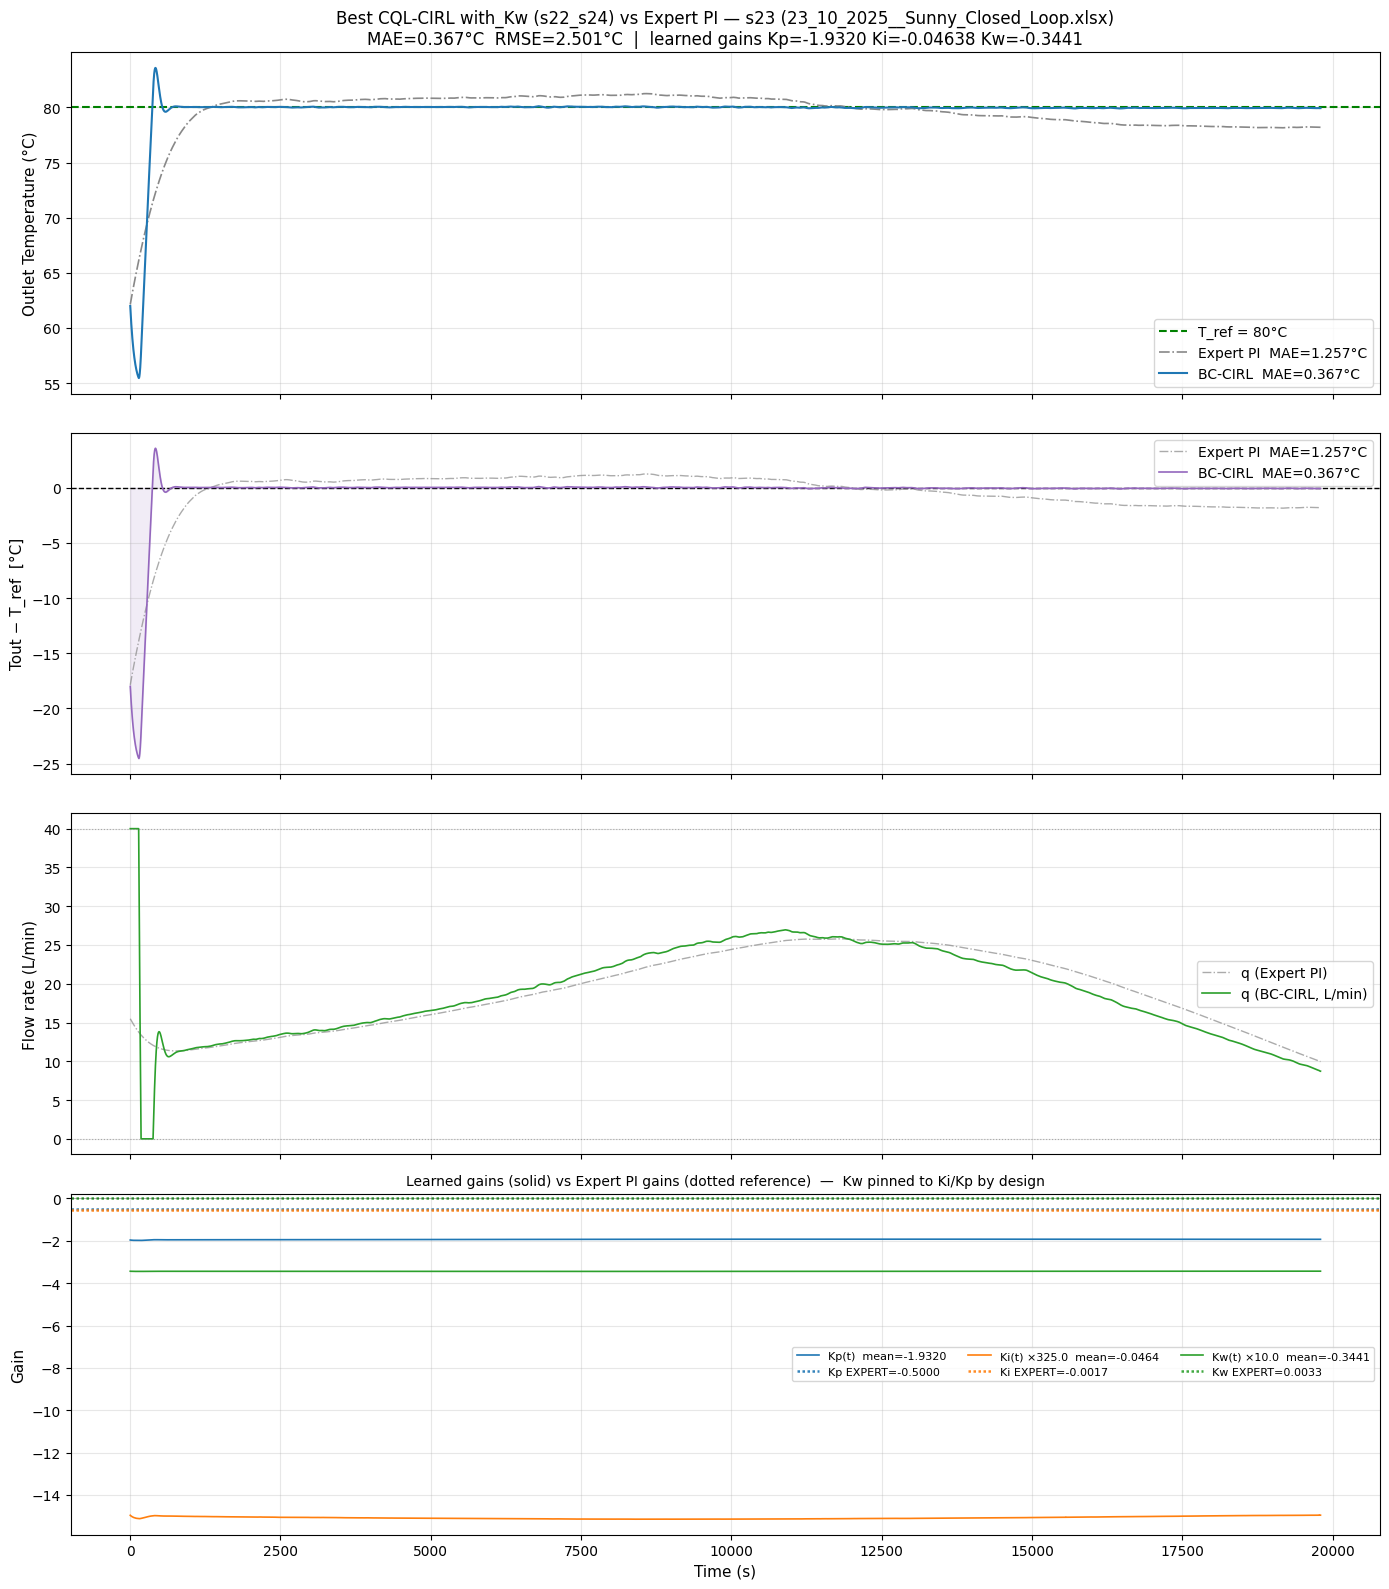

s23 (23_10_2025__Sunny_Closed_Loop.xlsx)  BC-CIRL MAE=0.367  Expert MAE=1.257  | learned Kp=-1.9320 Ki=-0.04638  vs  expert Kp=-0.5000 Ki=-0.00167


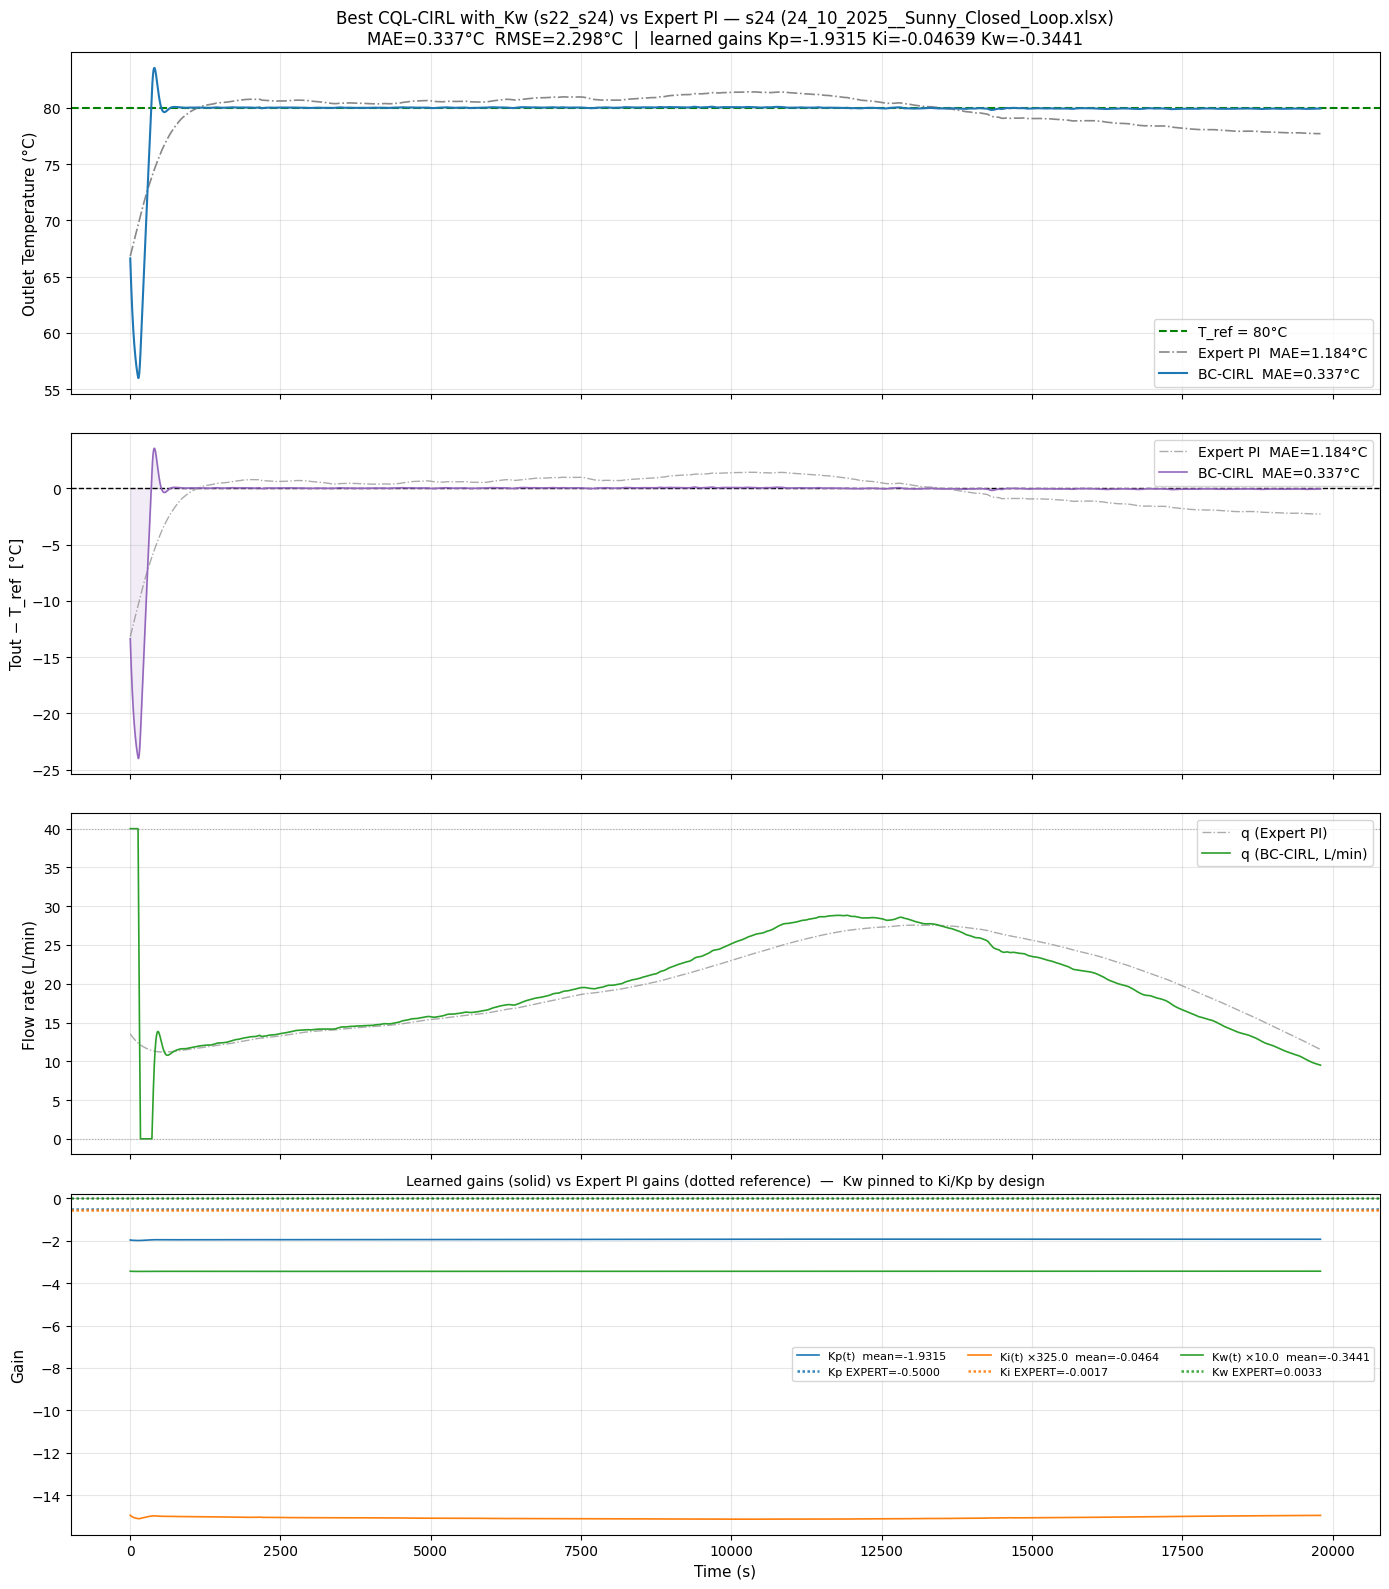

s24 (24_10_2025__Sunny_Closed_Loop.xlsx)  BC-CIRL MAE=0.337  Expert MAE=1.184  | learned Kp=-1.9315 Ki=-0.04639  vs  expert Kp=-0.5000 Ki=-0.00167


In [10]:
# ── Full-size 4-panel detail for the BEST policy — ON EVERY DATASET ───────────
# Panel 4 overlays the Expert PI gains (Kp, Ki, Kw) as dotted reference lines so
# you can compare the learned time-varying gains against the fixed expert gains.
best_combo = best_combo_all_ds   # best-generalising policy (avg MAE across all 5 datasets)
best_path  = os.path.join(SAVE_DIR, f'{PREFIX}{best_combo}.pt')
assert os.path.exists(best_path), f"Missing weights: {best_path}"

ALL_DATASETS = [
    "20_10_2025__Cloudy_Closed_Loop.xlsx",
    "21_10_2025__Sunny_Closed_Loop.xlsx",
    "22_10_2025__Sunny_Closed_Loop.xlsx",
    "23_10_2025__Sunny_Closed_Loop.xlsx",
    "24_10_2025__Sunny_Closed_Loop.xlsx",
]
DS_LABELS = ["s20", "s21", "s22", "s23", "s24"]
EXPERT_GAINS = {'Kp': KP_EXPERT, 'Ki': KI_EXPERT, 'Kw': KW}

for ds_file, ds_label in zip(ALL_DATASETS, DS_LABELS):
    ds_data = load_dataset(ds_file)
    tr      = dataset_tref(ds_file)

    Tout, q, Kp_arr, Ki_arr, Kw_arr = rollout_bc_cirl_setpoint_update(best_path, ds_data, tr)
    Tout_pi, q_pi = rollout_expert(ds_data, tr)
    n   = min(len(Tout), len(Tout_pi)); t = ds_data['time_ax'][1:n+1]
    err = Tout[:n] - tr
    mae_bc = float(np.mean(np.abs(err))); rmse_bc = float(np.sqrt(np.mean(err**2)))
    mae_pi = float(np.mean(np.abs(Tout_pi[:n] - tr)))
    Kp_m=float(np.mean(Kp_arr)); Ki_m=float(np.mean(Ki_arr)); Kw_m=float(np.mean(Kw_arr))

    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

    # ── Panel 1: T_ref + Expert PI + BC-CIRL Tout ──
    ax = axes[0]
    ax.axhline(tr, color='green', linewidth=1.5, linestyle='--', label=f'T_ref = {tr:.0f}°C')
    ax.plot(t, Tout_pi[:n], color='#888888', linewidth=1.2, linestyle='-.',
            label=f'Expert PI  MAE={mae_pi:.3f}°C')
    ax.plot(t, Tout[:n], color='#1f77b4', linewidth=1.5, label=f'BC-CIRL  MAE={mae_bc:.3f}°C')
    ax.set_ylabel('Outlet Temperature (°C)', fontsize=11)
    ax.set_title(f'Best CQL-CIRL with_Kw ({best_combo}) vs Expert PI — {ds_label} ({ds_file})\n'
                 f'MAE={mae_bc:.3f}°C  RMSE={rmse_bc:.3f}°C  |  '
                 f'learned gains Kp={Kp_m:.4f} Ki={Ki_m:.5f} Kw={Kw_m:.4f}', fontsize=12)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

    # ── Panel 2: Tracking error ──
    ax = axes[1]
    ax.axhline(0, color='black', linewidth=1.0, linestyle='--')
    exp_err = Tout_pi[:n] - tr
    ax.plot(t, exp_err, color='#888888', linewidth=1.0, linestyle='-.', alpha=0.7,
            label=f'Expert PI  MAE={mae_pi:.3f}°C')
    ax.plot(t, err, color='#9467bd', linewidth=1.2, label=f'BC-CIRL  MAE={mae_bc:.3f}°C')
    ax.fill_between(t, err, 0, alpha=0.12, color='#9467bd')
    ax.set_ylabel('Tout − T_ref  [°C]', fontsize=11); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

    # ── Panel 3: Flow rate q ──
    ax = axes[2]
    ax.plot(t, q_pi[:n], color='#888888', linewidth=1.0, linestyle='-.', alpha=0.7, label='q (Expert PI)')
    ax.plot(t, q[:n], color='#2ca02c', linewidth=1.2, label='q (BC-CIRL, L/min)')
    ax.axhline(Q_MIN, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.axhline(Q_MAX, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.set_ylabel('Flow rate (L/min)', fontsize=11); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

    # ── Panel 4: learned gains vs EXPERT PI gains (Manual Scaling) ──
    ax = axes[3]
    _gains  = {'Kp': Kp_arr[:n], 'Ki': Ki_arr[:n], 'Kw': Kw_arr[:n]}
    _means  = {'Kp': Kp_m, 'Ki': Ki_m, 'Kw': Kw_m}
    _colors = {'Kp': '#1f77b4', 'Ki': '#ff7f0e', 'Kw': '#2ca02c'}
    _styles = {'Kp': '-', 'Ki': '-', 'Kw': '-'}

    SCALE_FACTORS = {
        'Kp': 1.0,
        'Ki': 650.0/2,
        'Kw': 10.0
    }

    for name, arr in _gains.items():
        sf = SCALE_FACTORS[name]
        sf_tag = f' ×{sf}' if sf != 1.0 else ''
        ax.plot(t, arr * sf, color=_colors[name], linewidth=1.2, linestyle=_styles[name],
                label=f'{name}(t){sf_tag}  mean={_means[name]:.4f}')
        ax.axhline(EXPERT_GAINS[name] * sf, color=_colors[name], linewidth=1.8,
                   linestyle=(0,(1,1)), alpha=0.9,
                   label=f'{name} EXPERT={EXPERT_GAINS[name]:.4f}')

    ax.axhline(0, color='black', linewidth=0.6, linestyle='-', alpha=0.3)
    ax.set_ylabel('Gain', fontsize=11)
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_title('Learned gains (solid) vs Expert PI gains (dotted reference)  —  Kw pinned to Ki/Kp by design', fontsize=10)
    ax.legend(fontsize=8, ncol=3, loc='best')
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    out = os.path.join(CHART_DIR, f'cql_cirl_setpoint_anti_windup_best_{best_combo}_detail_{ds_label}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"{ds_label} ({ds_file})  BC-CIRL MAE={mae_bc:.3f}  Expert MAE={mae_pi:.3f}  "
          f"| learned Kp={Kp_m:.4f} Ki={Ki_m:.5f}  vs  expert Kp={KP_EXPERT:.4f} Ki={KI_EXPERT:.5f}")

Best-generalising policy: s22_s24  (lowest avg MAE across all 5 datasets)
Evaluating on all 5 datasets  (T_ref auto-selected)...



  s20 (65°C) T_ref=65°C:  BC MAE=0.4937°C  RMSE=1.7544°C  Expert MAE=2.1095°C


  s21 (80°C) T_ref=80°C:  BC MAE=0.3936°C  RMSE=2.7410°C  Expert MAE=1.0699°C


  s22 (80°C) T_ref=80°C:  BC MAE=0.3952°C  RMSE=2.6580°C  Expert MAE=1.1537°C


  s23 (80°C) T_ref=80°C:  BC MAE=0.3669°C  RMSE=2.5007°C  Expert MAE=1.2568°C


  s24 (80°C) T_ref=80°C:  BC MAE=0.3369°C  RMSE=2.2984°C  Expert MAE=1.1840°C


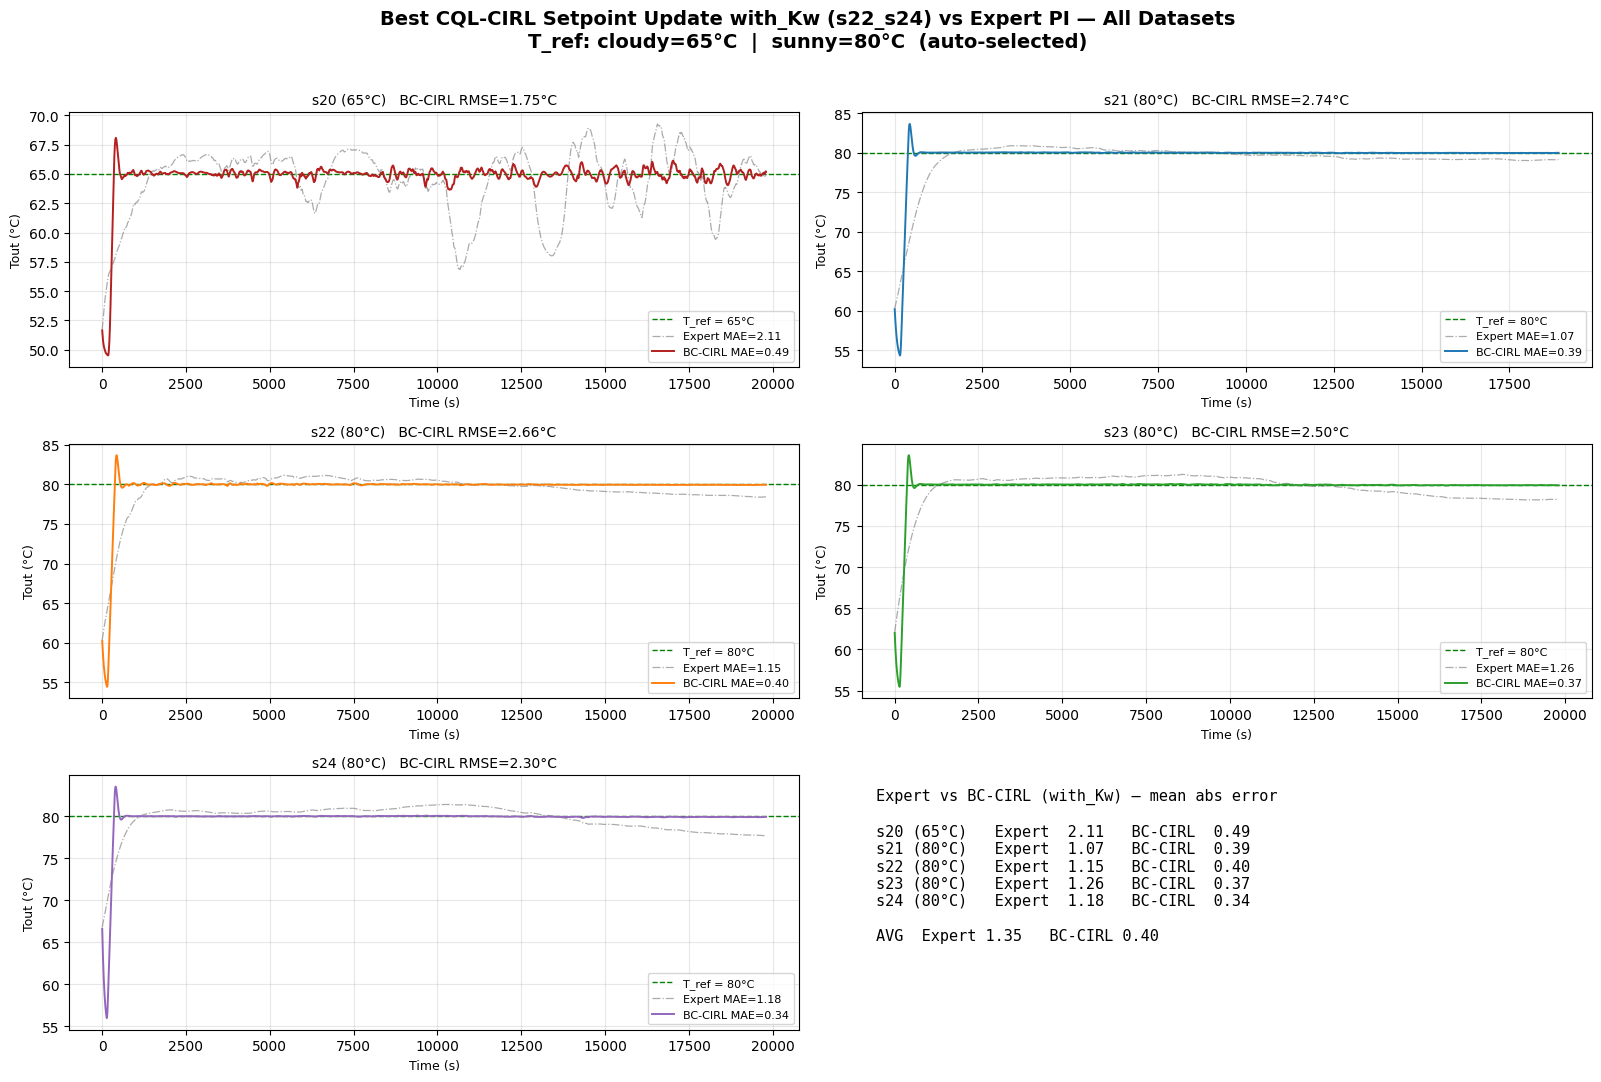


Saved: C:\Users\ap1125\Documents\Research Project\Materials\Solar Thermal Collector Materials\Imperial material\Closed loop - PI\SCF_Research_RL_Imperial\CQL Offline Actor\charts\cql_cirl_setpoint_anti_windup_best_s22_s24_all_datasets.png

Policy: s22_s24  —  performance across all datasets
       Dataset   T_ref      BC MAE     BC RMSE   Expert MAE   Kp_mean    Ki_mean   Kw_mean
------------------------------------------------------------------------------------------
    s20 (65°C)     65°C      0.4937      1.7544       2.1095   -1.8951   -0.04634   -0.3426
    s21 (80°C)     80°C      0.3936      2.7410       1.0699   -1.9416   -0.04623   -0.3439
    s22 (80°C)     80°C      0.3952      2.6580       1.1537   -1.9348   -0.04634   -0.3440
    s23 (80°C)     80°C      0.3669      2.5007       1.2568   -1.9320   -0.04638   -0.3441
    s24 (80°C)     80°C      0.3369      2.2984       1.1840   -1.9315   -0.04639   -0.3441
           AVG               0.3973      2.3905       1.3548


In [11]:
# ── Best policy evaluated on all 5 datasets ────────────────────────────────────
# T_ref is auto-selected per dataset: cloudy → 65°C, sunny → 80°C.
ALL_DATASETS = [
    "20_10_2025__Cloudy_Closed_Loop.xlsx",
    "21_10_2025__Sunny_Closed_Loop.xlsx",
    "22_10_2025__Sunny_Closed_Loop.xlsx",
    "23_10_2025__Sunny_Closed_Loop.xlsx",
    "24_10_2025__Sunny_Closed_Loop.xlsx",
]
DS_LABELS = ["s20 (65°C)", "s21 (80°C)", "s22 (80°C)", "s23 (80°C)", "s24 (80°C)"]
DS_COLORS = ["#b41f1f", '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

best_combo = best_combo_all_ds
best_path  = os.path.join(SAVE_DIR, f'{PREFIX}{best_combo}.pt')
assert os.path.exists(best_path), f"Missing weights: {best_path}"

print(f"Best-generalising policy: {best_combo}  (lowest avg MAE across all 5 datasets)")
print(f"Evaluating on all 5 datasets  (T_ref auto-selected)...\n")

fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex=False)
axes = axes.flatten()
all_ds_stats = []

for ds_idx, (ds_file, ds_label, ds_color) in enumerate(
        zip(ALL_DATASETS, DS_LABELS, DS_COLORS)):

    ds_data = load_dataset(ds_file)
    tr = dataset_tref(ds_file)   # 65°C for cloudy, 80°C for sunny

    Tout,    q,    Kp_arr, Ki_arr, Kw_arr = \
        rollout_bc_cirl_setpoint_update(best_path, ds_data)
    Tout_pi, q_pi = rollout_expert(ds_data)

    err_bc  = Tout    - tr
    err_pi  = Tout_pi - tr
    mae_bc  = float(np.mean(np.abs(err_bc)))
    rmse_bc = float(np.sqrt(np.mean(err_bc ** 2)))
    mae_pi  = float(np.mean(np.abs(err_pi)))

    all_ds_stats.append(dict(
        label=ds_label, file=ds_file, tref=tr,
        mae=mae_bc, rmse=rmse_bc, mae_pi=mae_pi,
        Kp_mean=float(np.mean(Kp_arr)),
        Ki_mean=float(np.mean(Ki_arr)),
        Kw_mean=float(np.mean(Kw_arr)),
    ))
    print(f"  {ds_label} T_ref={tr:.0f}°C:  "
          f"BC MAE={mae_bc:.4f}°C  RMSE={rmse_bc:.4f}°C  "
          f"Expert MAE={mae_pi:.4f}°C")

    t_ax = ds_data['time_ax'][1 : len(Tout) + 1]
    ax   = axes[ds_idx]
    ax.axhline(tr, color='green', linewidth=1.0, linestyle='--',
               label=f'T_ref = {tr:.0f}°C')
    ax.plot(t_ax, Tout_pi,
            color='#888888', linewidth=0.9, linestyle='-.', alpha=0.7,
            label=f'Expert MAE={mae_pi:.2f}')
    ax.plot(t_ax, Tout,
            color=ds_color, linewidth=1.4,
            label=f'BC-CIRL MAE={mae_bc:.2f}')
    ax.set_title(f"{ds_label}   BC-CIRL RMSE={rmse_bc:.2f}°C", fontsize=10)
    ax.set_ylabel('Tout (°C)', fontsize=9)
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# ── 6th panel (bottom-right): Expert vs BC-CIRL summary table ──────────────────
axes[-1].axis('off')
txt = "Expert vs BC-CIRL (with_Kw) — mean abs error\n\n"
for s in all_ds_stats:
    txt += f"{s['label']:<12} Expert {s['mae_pi']:5.2f}   BC-CIRL {s['mae']:5.2f}\n"
txt += (f"\nAVG  Expert {np.mean([s['mae_pi'] for s in all_ds_stats]):.2f}"
        f"   BC-CIRL {np.mean([s['mae'] for s in all_ds_stats]):.2f}")
axes[-1].text(0.02, 0.95, txt, va='top', family='monospace', fontsize=11)

fig.suptitle(
    f'Best CQL-CIRL Setpoint Update with_Kw ({best_combo}) vs Expert PI — All Datasets\n'
    f'T_ref: cloudy=65°C  |  sunny=80°C  (auto-selected)',
    fontsize=14, fontweight='bold',
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
out = os.path.join(CHART_DIR,
    f'cql_cirl_setpoint_anti_windup_best_{best_combo}_all_datasets.png')
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f"\nSaved: {out}")

# ── Cross-dataset summary ──────────────────────────────────────────────────────
print(f"\nPolicy: {best_combo}  —  performance across all datasets")
print(f"{'Dataset':>14}  {'T_ref':>6}  {'BC MAE':>10}  {'BC RMSE':>10}  "
      f"{'Expert MAE':>11}  {'Kp_mean':>8}  {'Ki_mean':>9}  {'Kw_mean':>8}")
print('-' * 90)
for s in all_ds_stats:
    print(f"  {s['label']:>12}  {s['tref']:>5.0f}°C"
          f"  {s['mae']:>10.4f}  {s['rmse']:>10.4f}  "
          f"{s['mae_pi']:>11.4f}  {s['Kp_mean']:>8.4f}  "
          f"{s['Ki_mean']:>9.5f}  {s['Kw_mean']:>8.4f}")
print(f"  {'AVG':>12}         "
      f"  {np.mean([s['mae'] for s in all_ds_stats]):>10.4f}  "
      f"{np.mean([s['rmse'] for s in all_ds_stats]):>10.4f}  "
      f"{np.mean([s['mae_pi'] for s in all_ds_stats]):>11.4f}")